# Análisis Exploratorio de Datos (EDA)

1. **Importaciones y Configuración**
2. **Carga de Datos**
3. **Inspección Inicial** — Inspección inicial, datos faltantes (nulos) y precio por m²
4. **Análisis Univariado** — Distribución de cada variable
5. **Análisis Bivariado** — Relaciones entre variables y el precio
6. **Feature Engineering** — Creación de nueva variables (amenity score, ratios, espaciales...)
7. **Análisis de Correlación** — Correlaciones con price
8. **Análisis de Multicolinealidad (VIF)** — 3 rondas iterativas para VIF
9. **Transformación Logarítmica del Target** — price vs log1p(price)

---

## 1. Importaciones y Configuración

In [1]:
import os
import sys
import warnings
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from folium.plugins import HeatMap, MarkerCluster
from scipy import stats
from scipy.stats import shapiro, skew, kurtosis
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# Añadir ml_pipeline al path para imports
ml_pipeline_path = os.path.abspath('..')
if ml_pipeline_path not in sys.path:
    sys.path.insert(0, ml_pipeline_path)

# Importar EDA personalizado y MLConfig
from eda_helper import EdaHelper
from ml_config import MLConfig

---

## 2. Carga de Datos

In [2]:
# CONFIGURACIÓN: Elegir fuente de datos
# Opciones: 'postgresql' o 'csv'
DATA_SOURCE = 'postgresql'  # Cambiar a 'csv' para leer desde archivo CSV

print(f"Fuente de datos: {DATA_SOURCE}")

Fuente de datos: postgresql


In [3]:
# CARGA DE DATOS

if DATA_SOURCE == 'postgresql':
    # Cargar desde PostgreSQL (Django ORM)
    import django
    from dotenv import load_dotenv

    # Permitir Django ORM en contexto asíncrono de Jupyter
    os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

    # Cargar .env desde la raíz del proyecto (TFM Repo/)
    project_path = os.path.abspath('../..')
    env_path = os.path.join(project_path, '.env')
    load_dotenv(dotenv_path=env_path)

    # DETECCIÓN AUTOMÁTICA DE ENTORNO:
    # Si POSTGRES_HOST=database (Docker), cambiar a localhost (ejecución local del notebook)
    postgres_host = os.getenv('POSTGRES_HOST', 'localhost')
    if postgres_host == 'database':
        postgres_host = 'localhost'

    os.environ['POSTGRES_HOST'] = postgres_host
    os.environ['POSTGRES_PORT'] = os.getenv('POSTGRES_PORT', '5432')
    os.environ['POSTGRES_DB'] = os.getenv('POSTGRES_DB', 'amsterdam_properties')
    os.environ['POSTGRES_USER'] = os.getenv('POSTGRES_USER', 'tfm_user')
    os.environ['POSTGRES_PASSWORD'] = os.getenv('POSTGRES_PASSWORD', '')

    # Añadir path del proyecto al PYTHONPATH
    sys.path.insert(0, project_path)
    sys.path.insert(0, os.path.join(project_path, 'backend'))

    # Configurar Django
    os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'config.settings')
    django.setup()

    from properties.models import Property
    
    # Cargar propiedades desde DB
    properties = Property.objects.filter(price__gt=0)
    df = pd.DataFrame(list(properties.values()))
    
    # Convertir Decimal a float
    decimal_columns = ['price', 'living_area', 'lot_area', 'latitude', 'longitude', 'predicted_price']
    for col in decimal_columns:
        if col in df.columns:
            df[col] = df[col].astype(float)
    
    print(f"- Cargadas {len(df):,} propiedades desde PostgreSQL")
    print(f"- Database: {os.environ['POSTGRES_HOST']}:{os.environ['POSTGRES_PORT']}")

else:
    # Cargar desde CSV
    csv_path = MLConfig.get_csv_path()
    df = pd.read_csv(csv_path)
    
    print(f"- Cargadas {len(df):,} propiedades desde CSV")
    print(f"- Archivo: {csv_path}")

- Cargadas 5,265 propiedades desde PostgreSQL
- Database: localhost:5432


---

## 3. Inspeccion Inicial

In [4]:
# Shape del dataset
print(f"SHAPE: {df.shape}")
print(f"- Filas (propiedades): {df.shape[0]:,}")
print(f"- Variables (columnas): {df.shape[1]}")

print(f"\nTotal de propiedades (filas): {len(df)}")
print(f"- Variables (columnas) disponibles: {df.shape[1]}")
print(f"- Variables (columnas): {list(df.columns)}")

print("\nPorcentaje de valores no nulos:")
coverage = (df.notna().sum() / len(df) * 100).sort_values(ascending=False)
for col, pct in coverage.items():
    status = "" if pct > 70 else "" if pct > 0 else ""
    print(f"{status} {col:20s}: {pct:5.1f}%")

SHAPE: (5265, 28)
- Filas (propiedades): 5,265
- Variables (columnas): 28

Total de propiedades (filas): 5265
- Variables (columnas) disponibles: 28
- Variables (columnas): ['id', 'title', 'description', 'property_type', 'url', 'price', 'predicted_price', 'address', 'neighborhood', 'city', 'zip_code', 'latitude', 'longitude', 'living_area', 'rooms', 'bedrooms', 'bathrooms', 'year_built', 'floor', 'energy_label', 'has_balcony', 'has_garden', 'is_furnished', 'has_parking', 'scraped_at', 'listed_since', 'updated_at', 'is_active']

Porcentaje de valores no nulos:
 id                  : 100.0%
 title               : 100.0%
 updated_at          : 100.0%
 listed_since        : 100.0%
 scraped_at          : 100.0%
 has_parking         : 100.0%
 is_furnished        : 100.0%
 has_garden          : 100.0%
 has_balcony         : 100.0%
 energy_label        : 100.0%
 is_active           : 100.0%
 city                : 100.0%
 neighborhood        : 100.0%
 description         : 100.0%
 zip_code     

In [5]:
# Primeras filas
df.head(10)

,id,title,description,property_type,url,price,predicted_price,address,neighborhood,city,zip_code,latitude,longitude,living_area,rooms,bedrooms,bathrooms,year_built,floor,energy_label,has_balcony,has_garden,is_furnished,has_parking,scraped_at,listed_since,updated_at,is_active
0,5265,Tweede Atjehstraat 8-E,Apartment for sale: Tweede Atjehstraat 8-E 109...,apartment,https://www.funda.nl/en/detail/koop/amsterdam/...,785000.0,763682.67,Tweede Atjehstraat 8-E,Oost,Amsterdam,1094 LE,52.361570,4.932293,93.0,3.0,2.0,1.0,2015.0,6.0,A,True,False,False,True,2026-05-04 06:28:12.967290+00:00,Log in to view,2026-05-04 06:28:12.967301+00:00,True
1,5264,Saffierstraat 3-B,Apartment for sale: Saffierstraat 3-B 1074 GH ...,apartment,https://www.funda.nl/en/detail/koop/amsterdam/...,525000.0,456005.79,Saffierstraat 3-B,Zuid,Amsterdam,1074 GH,52.351327,4.904661,58.0,3.0,2.0,1.0,1925.0,2.0,F,True,True,False,True,2026-05-04 06:28:12.709984+00:00,Log in to view,2026-05-04 06:28:12.709994+00:00,True
2,5263,Sanderijnstraat 58-3,Apartment for sale: Sanderijnstraat 58-3 1055 ...,apartment,https://www.funda.nl/en/detail/koop/amsterdam/...,775000.0,682744.39,Sanderijnstraat 58-3,West,Amsterdam,1055 BW,52.378174,4.850442,99.0,5.0,3.0,1.0,NaN,4.0,C,True,False,False,True,2026-05-04 06:28:12.650832+00:00,Log in to view,2026-05-04 06:28:12.650842+00:00,True
3,5262,Staringstraat 12-2,Apartment for sale: Staringstraat 12-2 1054 VP...,apartment,https://www.funda.nl/en/detail/koop/amsterdam/...,525000.0,563663.86,Staringstraat 12-2,West,Amsterdam,1054 VP,52.362137,4.862072,64.0,3.0,2.0,2.0,1903.0,2.0,C,True,False,False,True,2026-05-04 06:28:12.617083+00:00,Log in to view,2026-05-04 06:28:12.617095+00:00,True
4,5261,Trompenburgstraat 31-2,Apartment for sale: Trompenburgstraat 31-2 107...,apartment,https://www.funda.nl/en/detail/koop/amsterdam/...,880000.0,735104.94,Trompenburgstraat 31-2,Zuid,Amsterdam,1079 TM,52.343760,4.911538,95.0,4.0,3.0,1.0,NaN,3.0,A,True,True,False,True,2026-05-04 06:23:11.461171+00:00,Log in to view,2026-05-04 06:23:11.461180+00:00,True
5,5260,Van Ostadestraat 374-4,Apartment for sale: Van Ostadestraat 374-4 107...,apartment,https://www.funda.nl/en/detail/koop/amsterdam/...,495000.0,410215.39,Van Ostadestraat 374-4,Zuid,Amsterdam,1074 XA,52.354015,4.902813,45.0,2.0,1.0,1.0,1900.0,4.0,F,True,False,False,True,2026-05-04 06:23:11.418471+00:00,Log in to view,2026-05-04 06:23:11.418480+00:00,True
6,5259,Westlandgracht 195-3,Apartment for sale: Westlandgracht 195-3 1059 ...,apartment,https://www.funda.nl/en/detail/koop/amsterdam/...,865000.0,809355.57,Westlandgracht 195-3,Nieuw-West,Amsterdam,1059 TL,52.349771,4.846177,114.0,6.0,4.0,2.0,1933.0,3.0,C,True,False,False,True,2026-05-04 06:23:11.392317+00:00,Log in to view,2026-05-04 06:23:11.392327+00:00,True
7,5258,Ottho Heldringstraat 200-T,Apartment for sale: Ottho Heldringstraat 200-T...,apartment,https://www.funda.nl/en/detail/koop/amsterdam/...,585000.0,603163.36,Ottho Heldringstraat 200-T,Nieuw-West,Amsterdam,1066 AZ,52.348797,4.832084,105.0,4.0,3.0,1.0,2010.0,2.0,A+,True,False,False,True,2026-05-04 06:23:11.368165+00:00,Log in to view,2026-05-04 06:23:11.368174+00:00,True
8,5257,Tweede Atjehstraat 3-E,Apartment for sale: Tweede Atjehstraat 3-E 109...,apartment,https://www.funda.nl/en/detail/koop/amsterdam/...,400000.0,378160.25,Tweede Atjehstraat 3-E,Oost,Amsterdam,1094 KZ,52.361908,4.932483,45.0,2.0,1.0,1.0,1985.0,4.0,B,True,False,False,True,2026-05-04 06:23:11.342682+00:00,Log in to view,2026-05-04 06:23:11.342692+00:00,True
9,5256,Alexanderstraat 20,Apartment for sale: Alexanderstraat 20 1018 CE...,apartment,https://www.funda.nl/en/detail/koop/amsterdam/...,485000.0,454092.99,Alexanderstraat 20,Centrum,Amsterdam,1018 CE,52.363947,4.920718,49.0,2.0,1.0,1.0,1985.0,1.0,A,True,False,False,False,2026-05-04 06:23:11.317808+00:00,Log in to view,2026-05-04 06:23:11.317819+00:00,True


In [6]:
# Info general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5265 entries, 0 to 5264
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   id               5265 non-null   int64              
 1   title            5265 non-null   str                
 2   description      5265 non-null   str                
 3   property_type    5265 non-null   str                
 4   url              5265 non-null   str                
 5   price            5265 non-null   float64            
 6   predicted_price  925 non-null    float64            
 7   address          5265 non-null   str                
 8   neighborhood     5265 non-null   str                
 9   city             5265 non-null   str                
 10  zip_code         5265 non-null   str                
 11  latitude         4208 non-null   float64            
 12  longitude        4208 non-null   float64            
 13  living_area      5108 non-nul

In [7]:
# Estadísticas descriptivas
df.describe()

,id,price,predicted_price,latitude,longitude,living_area,rooms,bedrooms,bathrooms,year_built,floor
count,5265.000000,5.265000e+03,9.250000e+02,4208.000000,4208.000000,5108.000000,5119.000000,4922.000000,4342.000000,4481.000000,3785.000000
mean,2633.000000,7.400505e+05,5.703841e+05,52.361870,4.888788,91.421496,3.454776,2.271434,1.212114,1961.401027,3.173844
std,1520.018914,7.323577e+05,2.049660e+05,0.022622,0.047845,57.725255,1.611026,1.141072,0.550521,59.643035,3.016674
min,1.000000,5.950000e+02,2.190103e+05,52.289581,4.762817,1.000000,1.000000,1.000000,1.000000,1700.000000,0.000000
25%,1317.000000,4.200000e+05,4.036435e+05,52.350921,4.860353,58.000000,3.000000,2.000000,1.000000,1922.000000,1.000000
50%,2633.000000,5.650000e+05,5.097920e+05,52.361885,4.886779,77.000000,3.000000,2.000000,1.000000,1974.000000,3.000000
75%,3949.000000,7.950000e+05,6.869633e+05,52.375268,4.917678,105.000000,4.000000,3.000000,1.000000,2019.000000,4.000000
max,5265.000000,1.150000e+07,1.219758e+06,52.425110,5.028631,708.000000,17.000000,16.000000,9.000000,2026.000000,28.000000


In [8]:
# Valores nulos
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing (Count)': missing,
    'Percentage (%)': missing_pct
})
missing_df = missing_df[missing_df['Missing (Count)'] > 0].sort_values('Missing (Count)', ascending=False)

print("Valores faltantes (nulos):")
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No hay valores faltantes.")

Valores faltantes (nulos):
                 Missing (Count)  Percentage (%)
predicted_price             4340       82.431149
floor                       1480       28.110161
latitude                    1057       20.075973
longitude                   1057       20.075973
bathrooms                    923       17.530864
year_built                   784       14.890788
bedrooms                     343        6.514720
living_area                  157        2.981956
rooms                        146        2.773029


### 3.1 Creación de la variable: Precio por m²

Precio por m² (Estadísticas):
count     5099.000000
mean      8094.308306
std       2286.540191
min       3174.603175
25%       6583.124478
50%       8148.148148
75%       9265.686275
max      25291.828794
Name: price_per_m2, dtype: float64

Rango: 3175€ - 25292€ por m²


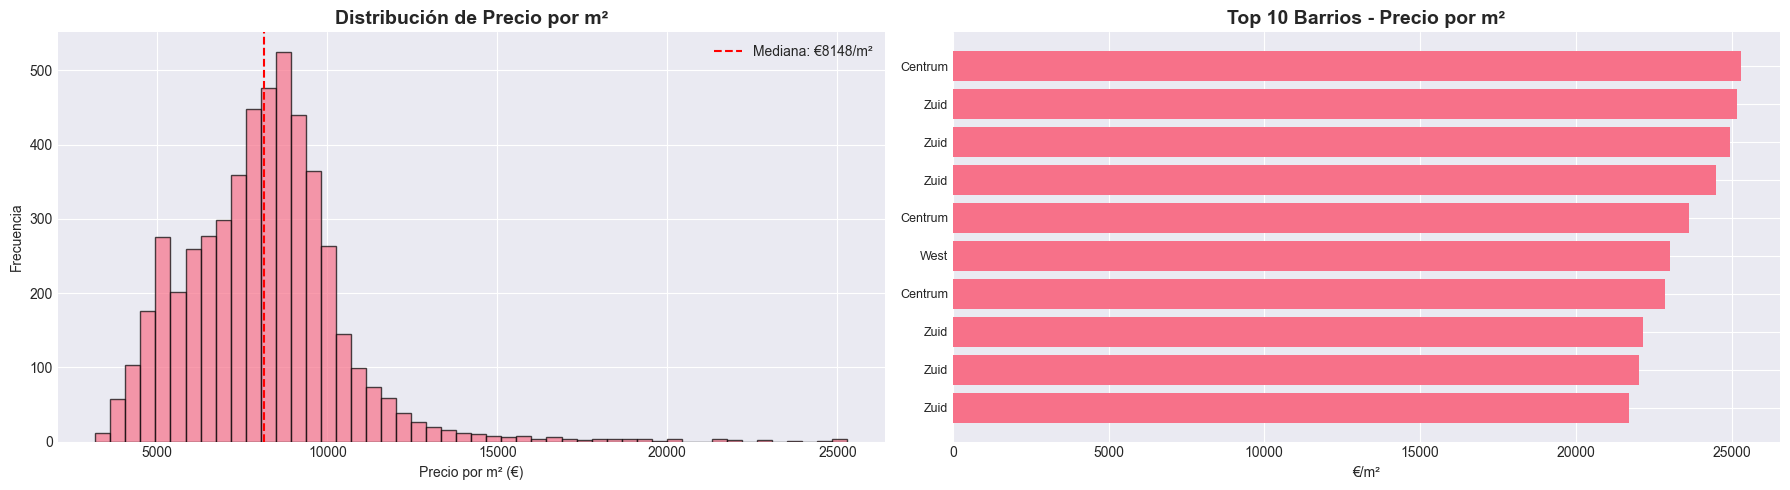

In [9]:
# Crear variable precio por metro cuadrado
PRICE_MIN = 100_000
PRICE_MAX = 10_000_000

df = df[(df['price'] >= PRICE_MIN) & (df['price'] <= PRICE_MAX)].copy()

df['price_per_m2'] = df['price'] / df['living_area']

print("Precio por m² (Estadísticas):")
print(df['price_per_m2'].describe())

print(f"\nRango: {df['price_per_m2'].min():.0f}€ - {df['price_per_m2'].max():.0f}€ por m²")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Histograma
axes[0].hist(df['price_per_m2'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Precio por m²', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio por m² (€)')
axes[0].set_ylabel('Frecuencia')

axes[0].axvline(
    df['price_per_m2'].median(),
    color='red',
    linestyle='--',
    label=f'Mediana: €{df["price_per_m2"].median():.0f}/m²'
)

axes[0].legend()

# Top 10 propiedades más caras por m2
top_expensive_m2 = df.nlargest(10, 'price_per_m2')[
    ['neighborhood', 'price_per_m2', 'living_area', 'price']
]

axes[1].barh(range(10), top_expensive_m2['price_per_m2'].values)

axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top_expensive_m2['neighborhood'].values, fontsize=9)

axes[1].set_title('Top 10 Barrios - Precio por m²', fontsize=14, fontweight='bold')
axes[1].set_xlabel('€/m²')

axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 3.2 Análisis de Datos Faltantes (Valores Nulos)

In [10]:
eda = EdaHelper(df)


Análisis de Missing Data:
         Column  Missing_Count  Missing_Pct
predicted_price           4211        81.99
          floor           1356        26.40
       latitude           1042        20.29
      longitude           1042        20.29
      bathrooms            801        15.60
     year_built            663        12.91
       bedrooms            225         4.38
    living_area             37         0.72
   price_per_m2             37         0.72
          rooms             26         0.51


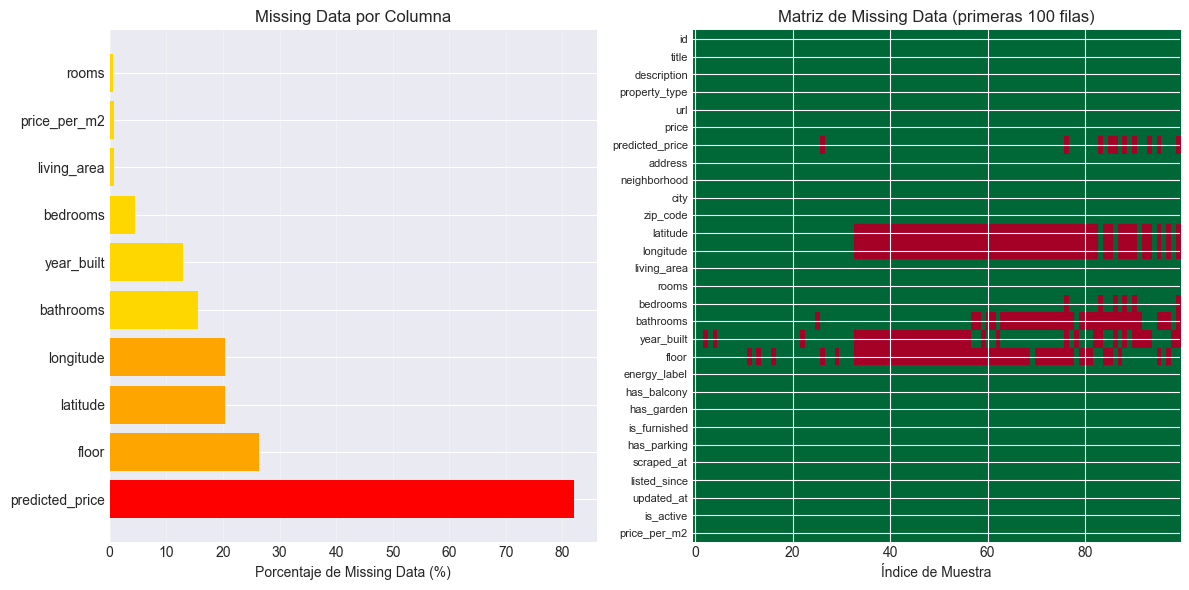


Columnas con datos faltantes (nulos):
         Column  Missing_Count  Missing_Pct
predicted_price           4211        81.99
          floor           1356        26.40
       latitude           1042        20.29
      longitude           1042        20.29
      bathrooms            801        15.60
     year_built            663        12.91
       bedrooms            225         4.38
    living_area             37         0.72
   price_per_m2             37         0.72
          rooms             26         0.51


In [11]:
# Análisis visual de datos faltantes
missing_stats = eda.plot_missing_data()

if len(missing_stats) > 0:
    print("\nColumnas con datos faltantes (nulos):")
    print(missing_stats[['Column', 'Missing_Count', 'Missing_Pct']].to_string(index=False))

---

## 4. Análisis Univariado


### 4.1 Estadísticas Descriptivas

In [12]:
# Estadísticas descriptivas de variables numéricas
numeric_cols = ['price', 'living_area', 'rooms', 'bedrooms', 'bathrooms', 'year_built']
available = [c for c in numeric_cols if c in df.columns]

if 'price_per_sqm' in df.columns:
    available.append('price_per_sqm')

if available:
    summary = eda.summary_statistics(available)
    print(summary)

              count           mean            std       min       25%  \
price        5136.0  753007.882009  702678.068490  100000.0  425000.0   
living_area  5099.0      91.378702      57.462546      19.0      58.0   
rooms        5110.0       3.453229       1.604842       1.0       3.0   
bedrooms     4911.0       2.270617       1.139313       1.0       2.0   
bathrooms    4335.0       1.211534       0.549578       1.0       1.0   
year_built   4473.0    1961.455846      59.645321    1700.0    1922.0   

                  50%       75%         max  missing  missing_pct  
price        575000.0  799000.0  10000000.0        0         0.00  
living_area      77.0     105.0       708.0       37         0.72  
rooms             3.0       4.0        17.0       26         0.51  
bedrooms          2.0       3.0        16.0      225         4.38  
bathrooms         1.0       1.0         9.0      801        15.60  
year_built     1974.0    2019.0      2026.0      663        12.91  


### 4.2 Price (Variable Objetivo)

In [13]:
# Estadísticas de precio
print("ESTADÍSTICAS DE PRECIO:")
print(f"Media:  €{df['price'].mean()}")
print(f"Mediana: €{df['price'].median()}")
print(f"Desv. Std: €{df['price'].std()}")
print(f"Min: €{df['price'].min()}")
print(f"Q1 (25%): €{df['price'].quantile(0.25)}")
print(f"Q3 (75%): €{df['price'].quantile(0.75)}")
print(f"Max: €{df['price'].max()}")
print(f"N: {len(df)}")

ESTADÍSTICAS DE PRECIO:
Media:  €753007.8820093458
Mediana: €575000.0
Desv. Std: €702678.0684900393
Min: €100000.0
Q1 (25%): €425000.0
Q3 (75%): €799000.0
Max: €10000000.0
N: 5136


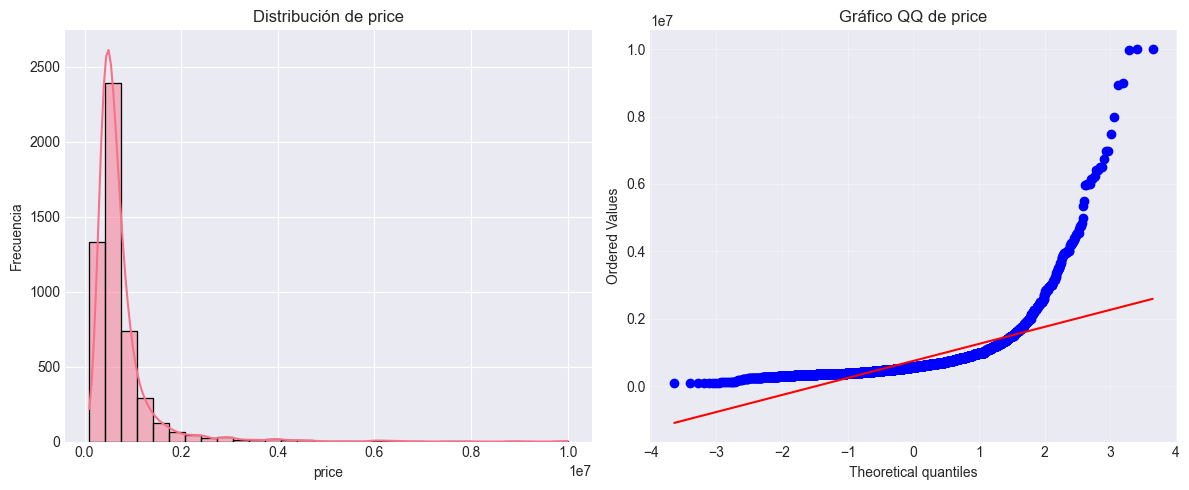

In [14]:
# Distribución de precio (Histograma + QQ-plot)
eda.plot_distribution('price')

In [15]:
# Test de normalidad (Shapiro-Wilk)

price_clean = df['price'].dropna()
sample_size = min(5000, len(price_clean))
stat, p_value = shapiro(price_clean.sample(sample_size, random_state=42))

print("TEST DE NORMALIDAD (Shapiro-Wilk):")
print(f"- Estadístico W: {stat:.6f}")
print(f"- P-value: {p_value:.8f}")
print(f"- Muestra usada: {sample_size:,} muestras ({len(price_clean):,} no nulas)")

if p_value > 0.05:
    print("-> Sigue distribución NORMAL (p > 0.05)")
else:
    print("-> NO sigue distribución normal (p <= 0.05)")

TEST DE NORMALIDAD (Shapiro-Wilk):
- Estadístico W: 0.512438
- P-value: 0.00000000
- Muestra usada: 5,000 muestras (5,136 no nulas)
-> NO sigue distribución normal (p <= 0.05)


In [16]:
# Skewness y Kurtosis
skewness = df['price'].skew()
kurt = df['price'].kurtosis()

print("FORMA DE LA DISTRIBUCION")
print(f"Skewness: {skewness:.3f}")
if skewness > 0.5:
    print("- Asimetría POSITIVA (Cola hacia la derecha -> Precios altos)")
elif skewness < -0.5:
    print("- Asimetría NEGATIVA (Cola hacia la izquierda -> Precios bajos)")
else:
    print("- Aproximadamente SIMÉTRICA")

print(f"\nKurtosis: {kurt:.3f}")
if kurt > 3:
    print("- LEPTOCÚRTICA: Picos altos, colas pesadas")
elif kurt < 3:
    print("- PLATICÚRTICA: Picos bajos, colas ligeras")
else:
    print("- MESOCÚRTICA: Distribución normal")

FORMA DE LA DISTRIBUCION
Skewness: 5.565
- Asimetría POSITIVA (Cola hacia la derecha -> Precios altos)

Kurtosis: 45.611
- LEPTOCÚRTICA: Picos altos, colas pesadas


ANÁLISIS DE OUTLIERS - PRICE (Método IQR)
Q1: 425000.00
Q3: 799000.00
IQR: 374000.00
Límite inferior: -136000.00
Límite superior: 1360000.00

Outliers detectados: 409 (8.0%)


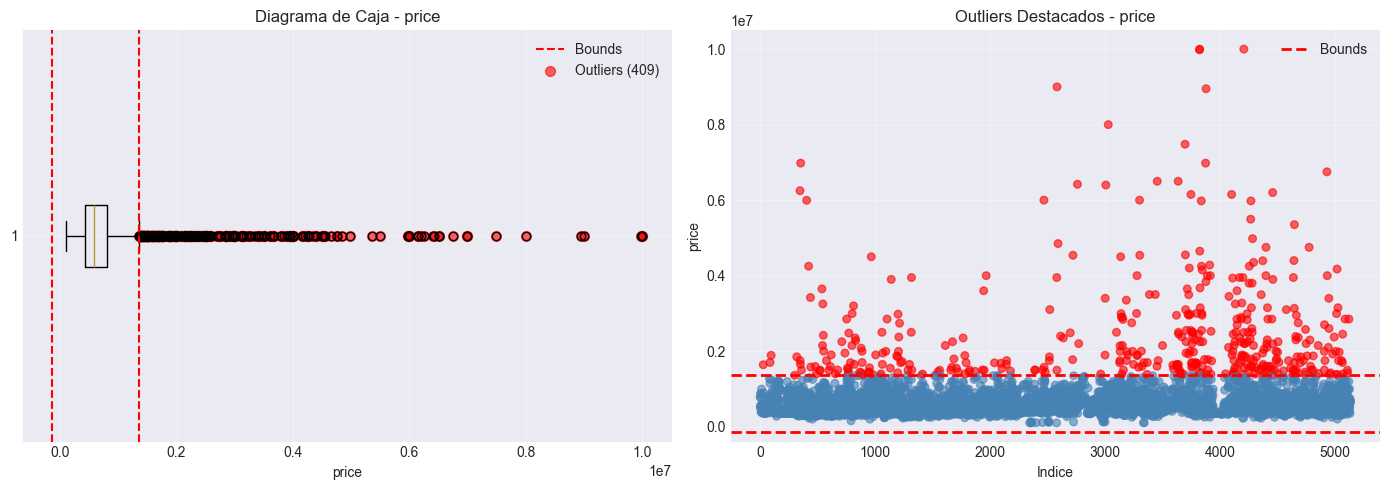

In [17]:
# Análisis de outliers en price
if 'price' in df.columns:
    outlier_stats_price = eda.plot_outliers_analysis('price', method='IQR', threshold=1.5)

### 4.3 Living Area (Superfície Habitable)

In [18]:
# Estadísticas de living area
area_col = 'living_area' if 'living_area' in df.columns else 'area'

if area_col in df.columns:
    print("ESTADÍSTICAS DE LIVING AREA")
    print(f"- Media: {df[area_col].mean()} m²")
    print(f"- Mediana: {df[area_col].median()} m²")
    print(f"- Desv. Std: {df[area_col].std()} m²")
    print(f"- Min: {df[area_col].min()} m²")
    print(f"- Max: {df[area_col].max()} m²")
else:
    print("Variable 'living_area' o 'area' no encontrada")

ESTADÍSTICAS DE LIVING AREA
- Media: 91.3787017062169 m²
- Mediana: 77.0 m²
- Desv. Std: 57.462546396150906 m²
- Min: 19.0 m²
- Max: 708.0 m²


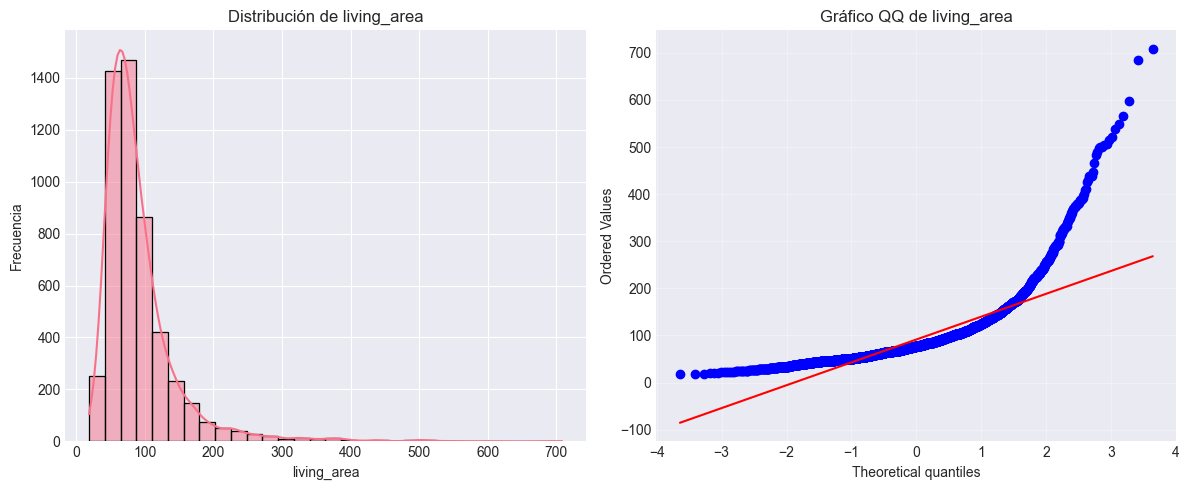


Shapiro-Wilk Test: stat=0.7124, p-value=0.000000
Muestra usada: 5,000 de 5,099 no nulos
Conclusión: NO sigue distribución normal


In [19]:
# Distribucion y test de normalidad
if area_col in df.columns:
    eda.plot_distribution(area_col)

    # Shapiro test (sample size sobre la serie ya limpia)
    area_clean = df[area_col].dropna()
    sample_size = min(5000, len(area_clean))
    stat, p = shapiro(area_clean.sample(sample_size, random_state=42))
    print(f"\nShapiro-Wilk Test: stat={stat:.4f}, p-value={p:.6f}")
    print(f"Muestra usada: {sample_size:,} de {len(area_clean):,} no nulos")
    if p > 0.05:
        print("Conclusión: Sigue distribución NORMAL")
    else:
        print("Conclusión: NO sigue distribución normal")

ANÁLISIS DE OUTLIERS - LIVING_AREA (Método IQR)
Q1: 58.00
Q3: 105.00
IQR: 47.00
Límite inferior: -12.50
Límite superior: 175.50

Outliers detectados: 305 (6.0%)


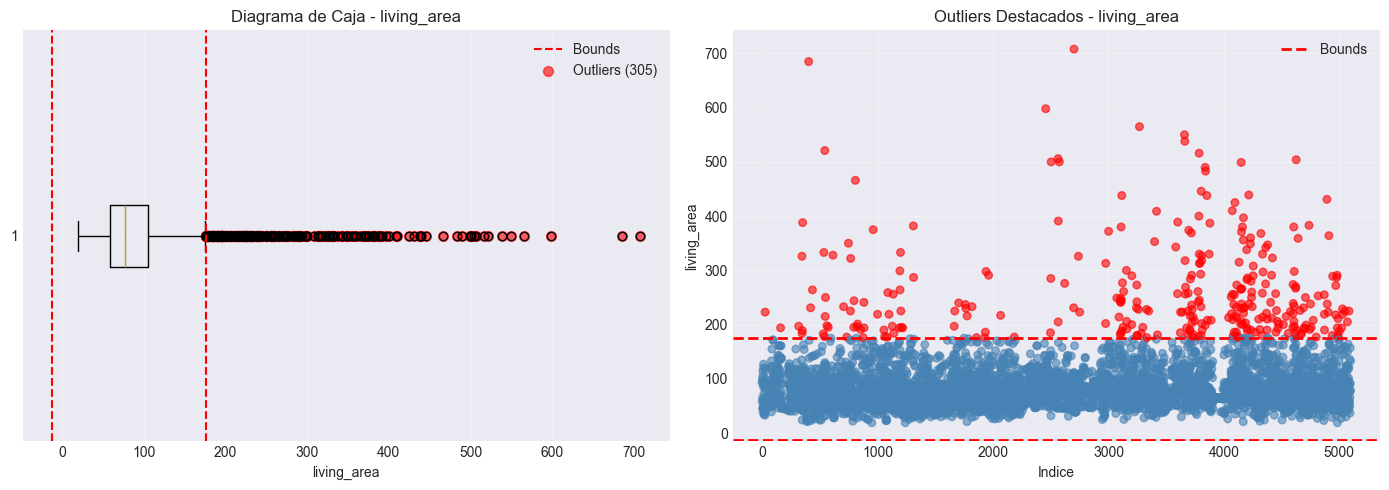

In [20]:
# Analisis de outliers en living_area
if 'living_area' in df.columns:
    outlier_stats_area = eda.plot_outliers_analysis('living_area', method='IQR', threshold=1.5)

### 4.4 Rooms

INFO 2026-05-12 12:56:13,427 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO 2026-05-12 12:56:13,437 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


DISTRIBUCIÓN DE ROOMS
rooms
1.0      175
2.0     1045
3.0     2003
4.0     1068
5.0      402
6.0      191
7.0       94
8.0       49
9.0       30
10.0      19
11.0       7
12.0       9
13.0      12
14.0       3
17.0       3
Name: count, dtype: int64


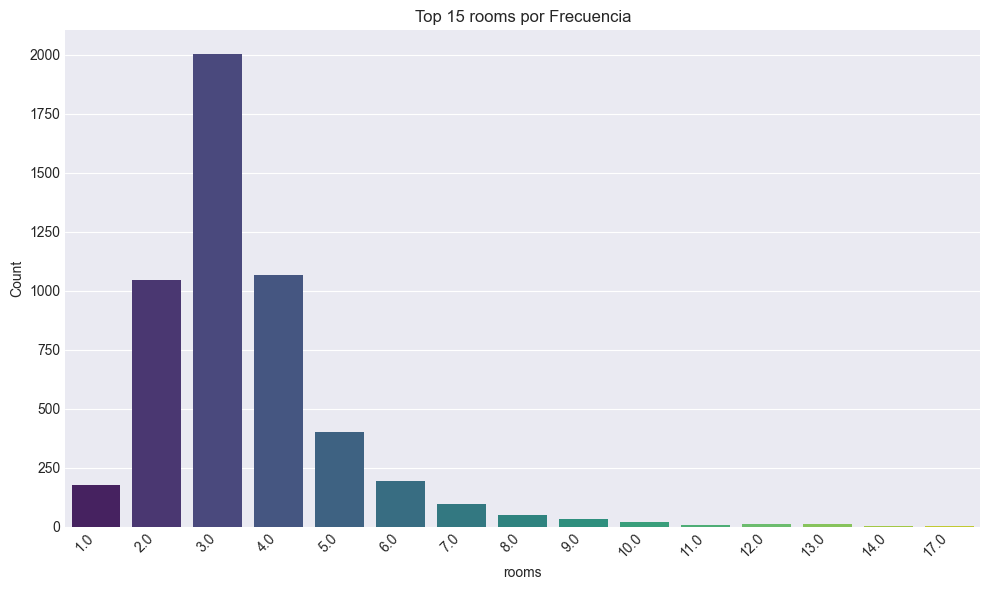

In [21]:
# Distribución de habitaciones
if 'rooms' in df.columns:
    print("DISTRIBUCIÓN DE ROOMS")
    print(df['rooms'].value_counts().sort_index())

    eda.plot_counts('rooms', top_n=15)
else:
    print("Variable 'rooms' no encontrada")

INFO 2026-05-12 12:56:13,646 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO 2026-05-12 12:56:13,680 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


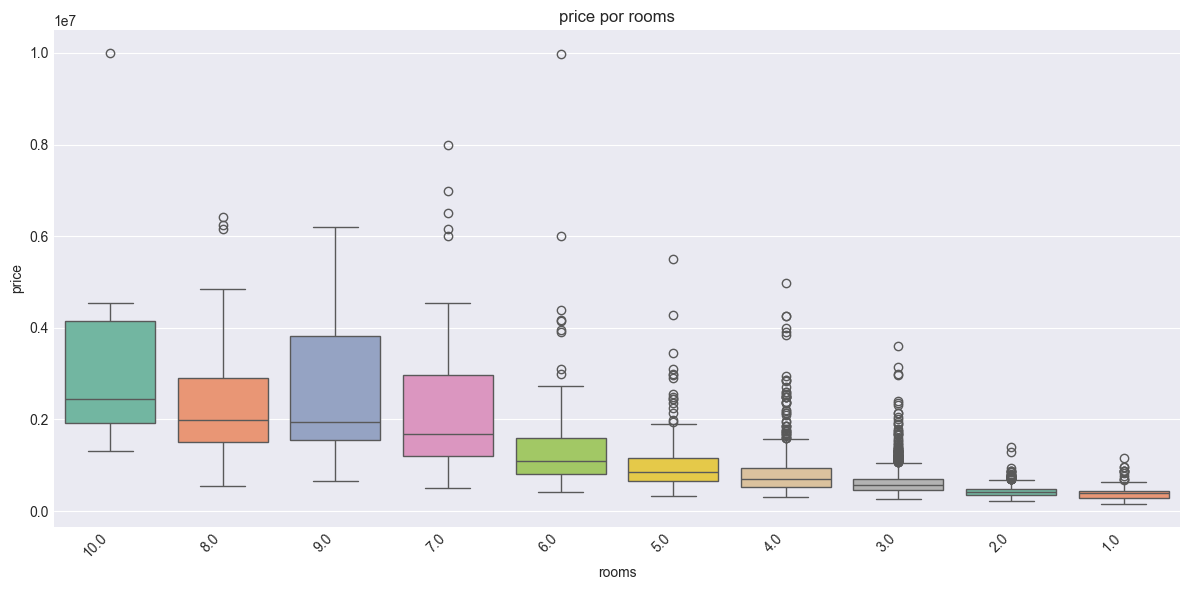

In [22]:
# Diagrama de cajas price por rooms
if 'rooms' in df.columns:
    eda.plot_boxplot_by_category('rooms', 'price', top_n=10)

### 4.5 Bedrooms

INFO 2026-05-12 12:56:14,231 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO 2026-05-12 12:56:14,240 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


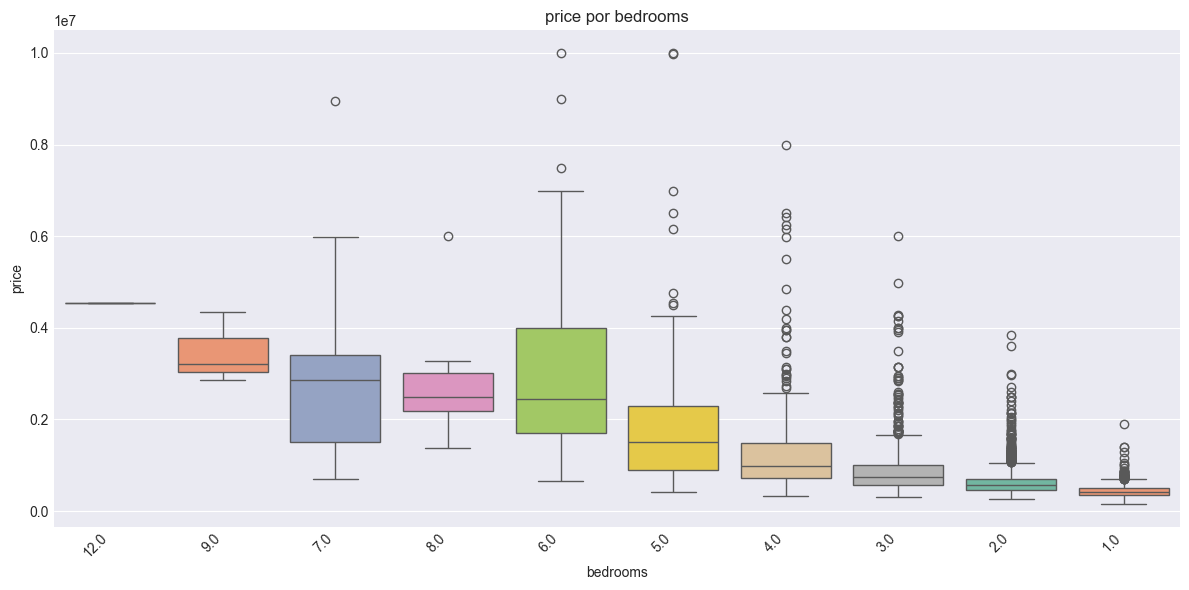

In [23]:
# Distribución de precio por número de dormitorios
if 'bedrooms' in df.columns:
    eda.plot_boxplot_by_category('bedrooms', 'price', top_n=10)

ESTADÍSTICAS DE BEDROOMS
Media: 2.27
Mediana: 2.00
Min: 1
Max: 16

Distribución:
bedrooms
1.0     1199
2.0     2091
3.0     1052
4.0      357
5.0      142
6.0       41
7.0       17
8.0        7
9.0        3
12.0       1
16.0       1
Name: count, dtype: int64


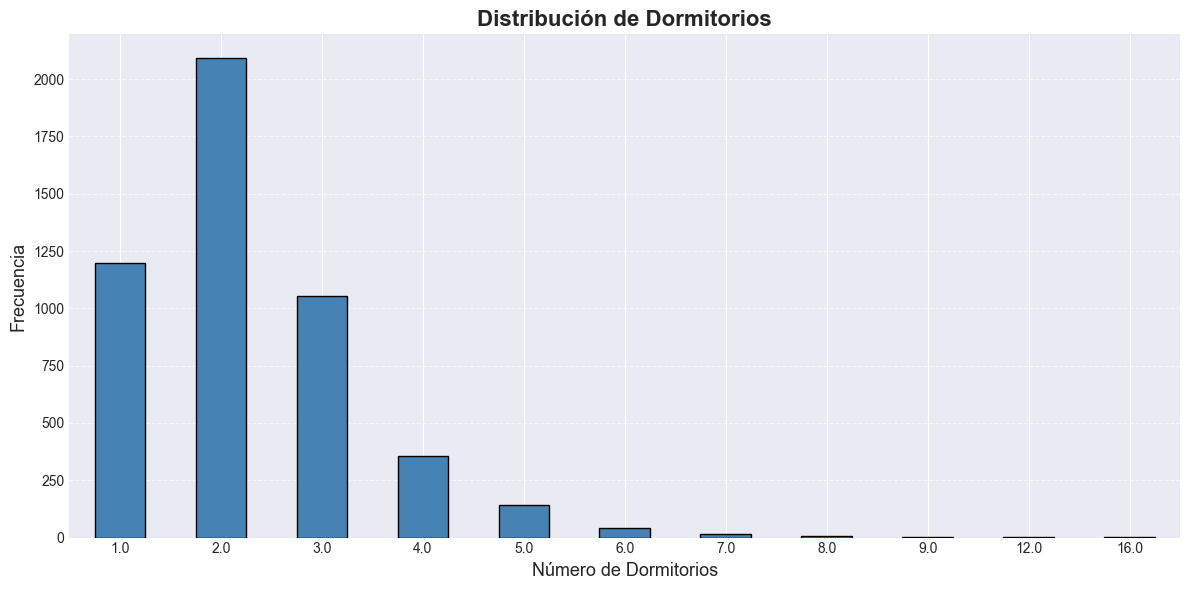

In [24]:
# Análisis de bedrooms
if 'bedrooms' in df.columns:
    print("ESTADÍSTICAS DE BEDROOMS")
    print(f"Media: {df['bedrooms'].mean():.2f}")
    print(f"Mediana: {df['bedrooms'].median():.2f}")
    print(f"Min: {df['bedrooms'].min():.0f}")
    print(f"Max: {df['bedrooms'].max():.0f}")
    print("\nDistribución:")
    print(df['bedrooms'].value_counts().sort_index())

    # Bar plot
    plt.figure(figsize=(12, 6))
    bedrooms_counts = df['bedrooms'].value_counts().sort_index()
    bedrooms_counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Distribución de Dormitorios', fontsize=16, fontweight='bold')
    plt.xlabel('Número de Dormitorios', fontsize=13)
    plt.ylabel('Frecuencia', fontsize=13)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Variable 'bedrooms' no encontrada")

### 4.6 Bathrooms

DISTRIBUCIÓN DE BAÑOS
bathrooms
1.0    3616
2.0     575
3.0     110
4.0      23
5.0       8
6.0       1
9.0       2
Name: count, dtype: int64


INFO 2026-05-12 12:56:14,905 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO 2026-05-12 12:56:14,924 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


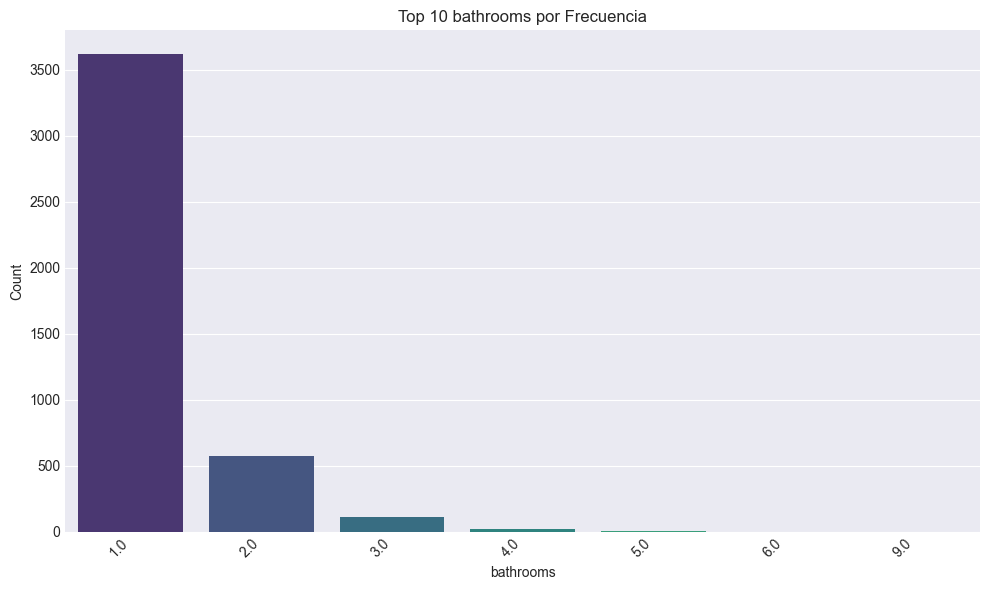

In [25]:
# Distribución de baños
if 'bathrooms' in df.columns:
    print("DISTRIBUCIÓN DE BAÑOS")
    print(df['bathrooms'].value_counts().sort_index())

    eda.plot_counts('bathrooms', top_n=10)
else:
    print("Variable 'bathrooms' no encontrada")

INFO 2026-05-12 12:56:15,527 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO 2026-05-12 12:56:15,556 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


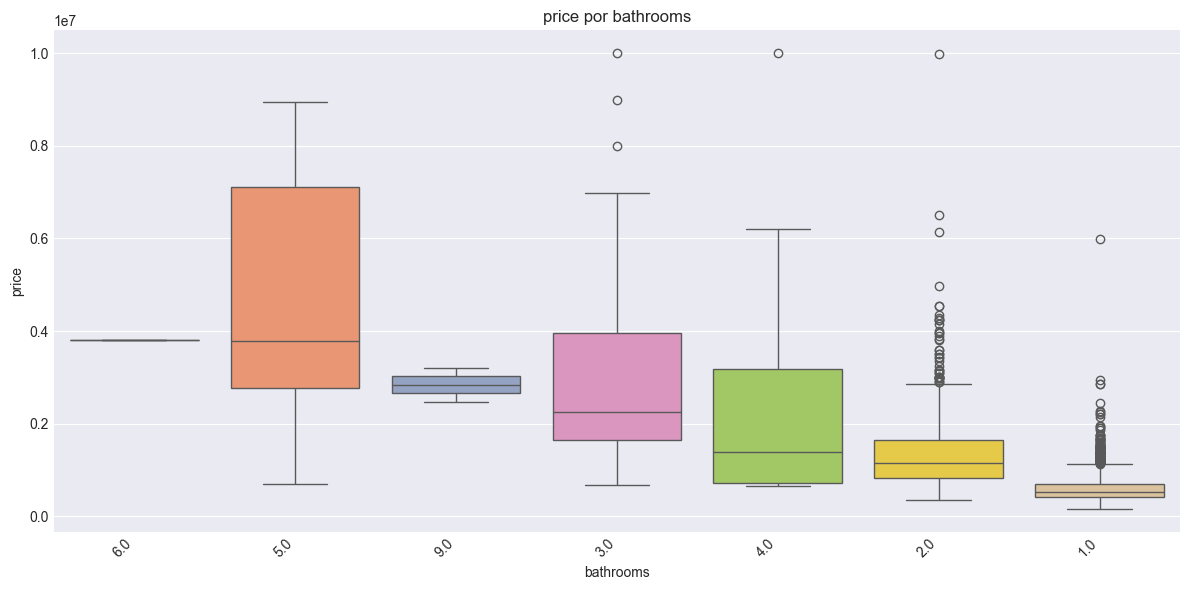

In [26]:
# Distribución de precio por número de baños
if 'bathrooms' in df.columns:
    eda.plot_boxplot_by_category('bathrooms', 'price', top_n=8)

### 4.7 Property Type

TIPOS DE PROPIEDAD
               Count  Percentage (%)
property_type                       
apartment       4555           88.69
house            581           11.31


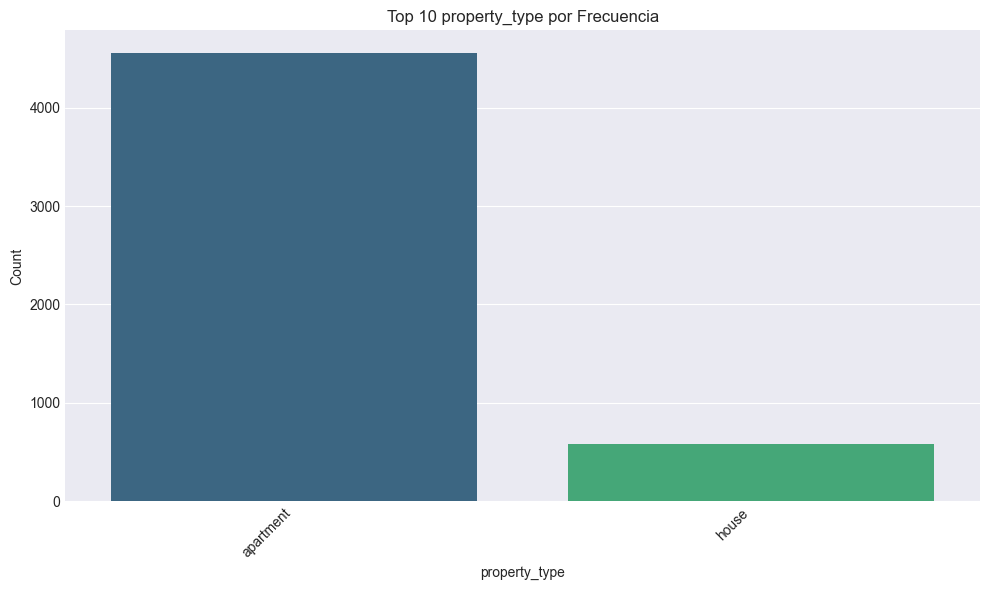

In [27]:
# Tipos de propiedad
if 'property_type' in df.columns:
    print("TIPOS DE PROPIEDAD")

    type_counts = df['property_type'].value_counts()
    type_pct = (type_counts / len(df) * 100).round(2)

    type_df = pd.DataFrame({
    'Count': type_counts,
    'Percentage (%)': type_pct
    })

    print(type_df)

    eda.plot_counts('property_type', top_n=10)
else:
    print("Variable 'property_type' no encontrada")

### 4.8 Segmentación por tipo de propiedad

SEGMENTACIÓN POR TIPO DE PROPIEDAD
               Precio_Medio  Precio_Mediana  Cantidad  Precio_por_m2  \
property_type                                                          
apartment         678434.85        550000.0      4555        8147.81   
house            1337655.34        850000.0       581        7659.79   

               Area_Media  Rooms_Promedio  Bathrooms_Promedio  %_Balcón  \
property_type                                                             
apartment           82.29            3.17                1.15     75.94   
house              165.18            5.73                1.67     41.48   

               %_Jardín  %_Parking  
property_type                       
apartment         46.43      90.85  
house             84.51      96.04  


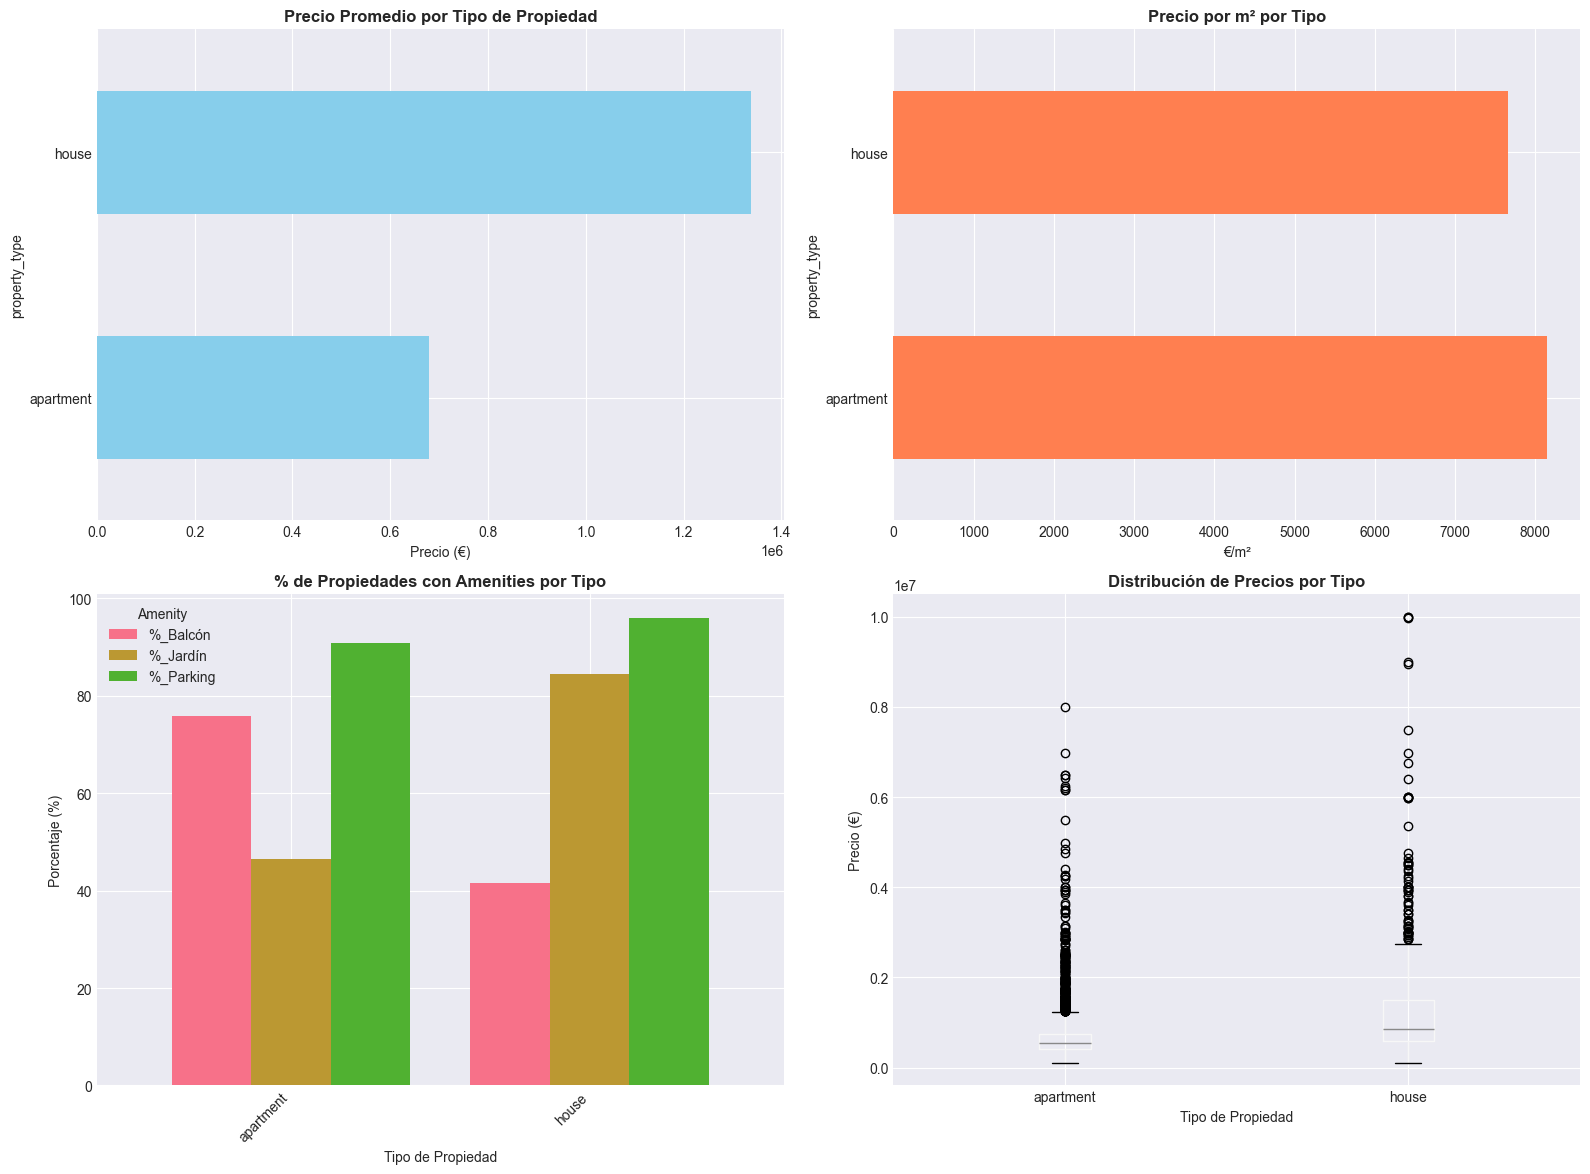

In [28]:
# Análisis comparativo por tipo de propiedad

segmentation = df.groupby('property_type').agg({
    'price': ['mean', 'median', 'count'],
    'price_per_m2': 'mean',
    'living_area': 'mean',
    'rooms': 'mean',
    'bathrooms': 'mean',
    'has_balcony': lambda x: (x == 1).sum() / len(x) * 100, # Ptc con balcón
    'has_garden': lambda x: (x == 1).sum() / len(x) * 100, # Ptc con jardín
    'has_parking': lambda x: (x == 1).sum() / len(x) * 100 # Ptc con parking
}).round(2)

segmentation.columns = ['Precio_Medio', 'Precio_Mediana', 'Cantidad', 'Precio_por_m2', 
    'Area_Media', 'Rooms_Promedio', 'Bathrooms_Promedio',
    '%_Balcón', '%_Jardín', '%_Parking']

print("SEGMENTACIÓN POR TIPO DE PROPIEDAD")
print(segmentation)

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Precio promedio por tipo
segmentation['Precio_Medio'].plot(kind='barh', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Precio Promedio por Tipo de Propiedad', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Precio (€)')

# 2. Precio por m² por tipo
segmentation['Precio_por_m2'].plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Precio por m² por Tipo', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('€/m²')

# 3. Distribución de amenities
amenities_cols = ['%_Balcón', '%_Jardín', '%_Parking']
segmentation[amenities_cols].plot(kind='bar', ax=axes[1, 0], width=0.8)
axes[1, 0].set_title('% de Propiedades con Amenities por Tipo', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Porcentaje (%)')
axes[1, 0].set_xlabel('Tipo de Propiedad')
axes[1, 0].legend(title='Amenity', loc='best')
axes[1, 0].set_xticklabels(segmentation.index, rotation=45, ha='right')

# 4. Boxplot de precios por tipo
df.boxplot(column='price', by='property_type', ax=axes[1, 1])
axes[1, 1].set_title('Distribución de Precios por Tipo', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tipo de Propiedad')
axes[1, 1].set_ylabel('Precio (€)')
plt.suptitle('')

plt.tight_layout()
plt.show()

### 4.9 Neighborhood

In [29]:
# Barrios únicos y distribución
if 'neighborhood' in df.columns:
    print("ANÁLISIS DE NEIGHBORHOODS")
    print(f"\nTotal neighborhoods únicos: {df['neighborhood'].nunique()}")
    print(f"\nRecuento de los neighborhoods:")
    print(df['neighborhood'].value_counts())
else:
    print("Variable 'neighborhood' no encontrada")

# Barrios con nombre vacío o NaN
empty_nb = df[df['neighborhood'].isna() | (df['neighborhood'].str.strip() == '')]
if len(empty_nb) > 0:
    print(f"\nPropiedades sin barrio asignado: {len(empty_nb)} ({len(empty_nb)/len(df)*100:.1f}%) con precio medio: €{empty_nb['price'].mean():,.0f}")
    print("-> Asignación del valor de 'Unknown' a los barrios vacíos o nulos.")
    df['neighborhood'] = df['neighborhood'].fillna('Unknown').replace('', 'Unknown').str.strip().replace('', 'Unknown')


ANÁLISIS DE NEIGHBORHOODS

Total neighborhoods únicos: 8

Recuento de los neighborhoods:
neighborhood
Zuid          1013
Centrum        780
Nieuw-West     769
West           697
Oost           665
Zuidoost       535
Noord          525
               152
Name: count, dtype: int64

Propiedades sin barrio asignado: 152 (3.0%) con precio medio: €807,796
-> Asignación del valor de 'Unknown' a los barrios vacíos o nulos.


In [30]:
# TABLA COMPARATIVA por neighborhood (Top 8)
if 'neighborhood' in df.columns:
    total_properties = len(df)

    # Agrupar y calcular estadisticas
    neighborhood_stats = df.groupby('neighborhood').agg({
    'price': ['count', 'mean', 'median', 'std']
    }).round(0)

    neighborhood_stats.columns = ['Count_Properties', 'Avg_Price', 'Median_Price', 'Std_Price']

    # Calcular share de propiedades (%)
    neighborhood_stats['Share_of_Properties_%'] = (
    neighborhood_stats['Count_Properties'] / total_properties * 100
    ).round(2)

    # Ordenar por numero de propiedades
    neighborhood_stats = neighborhood_stats.sort_values('Count_Properties', ascending=False)

    # Top 8 neighborhoods
    print("TABLA COMPARATIVA POR NEIGHBORHOOD (Top 8)")
    print(neighborhood_stats.head(8).to_string())

    top_neighborhoods = neighborhood_stats.head(8)

TABLA COMPARATIVA POR NEIGHBORHOOD (Top 8)
              Count_Properties  Avg_Price  Median_Price  Std_Price  Share_of_Properties_%
neighborhood                                                                             
Zuid                      1013  1072838.0      695000.0  1173175.0                  19.72
Centrum                    780  1025319.0      745000.0   825792.0                  15.19
Nieuw-West                 769   578349.0      535000.0   223675.0                  14.97
West                       697   632809.0      525000.0   484463.0                  13.57
Oost                       665   634187.0      595000.0   290413.0                  12.95
Zuidoost                   535   413467.0      360370.0   117280.0                  10.42
Noord                      525   627376.0      530000.0   340421.0                  10.22
Unknown                    152   807796.0      798000.0   266324.0                   2.96


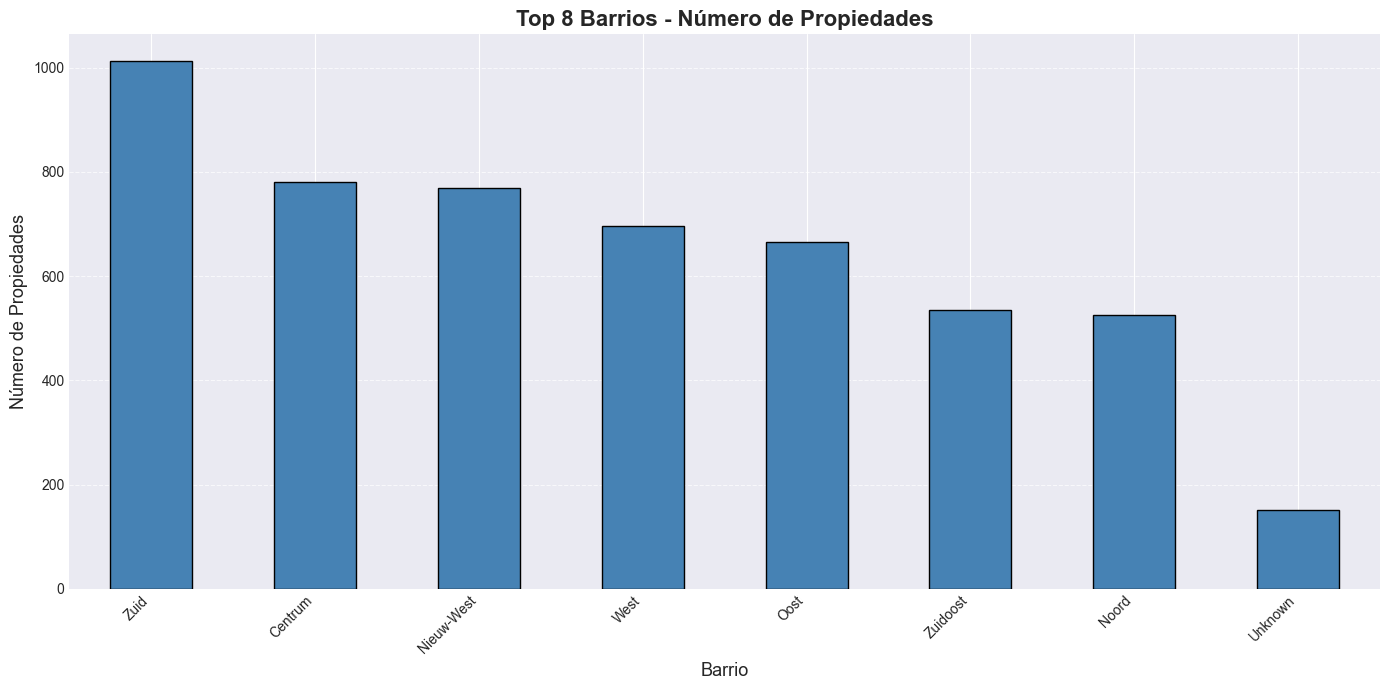

In [31]:
# Gráfico de barras: Count por neighborhood (Top 8)
if 'neighborhood' in df.columns:
    top_8 = df['neighborhood'].value_counts().head(8)

    plt.figure(figsize=(14, 7))
    top_8.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Top 8 Barrios - Número de Propiedades', fontsize=16, fontweight='bold')
    plt.xlabel('Barrio', fontsize=13)
    plt.ylabel('Número de Propiedades', fontsize=13)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

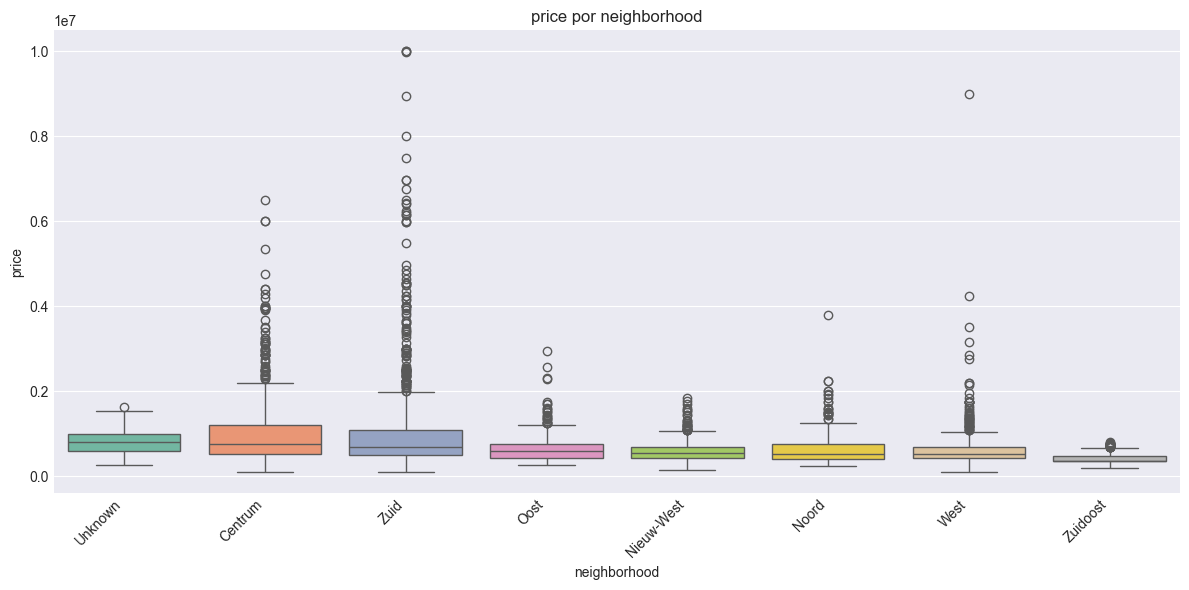

In [32]:
# Distribución de precio por barrio (Top 8)
if 'neighborhood' in df.columns:
    eda.plot_boxplot_by_category('neighborhood', 'price', top_n=15)

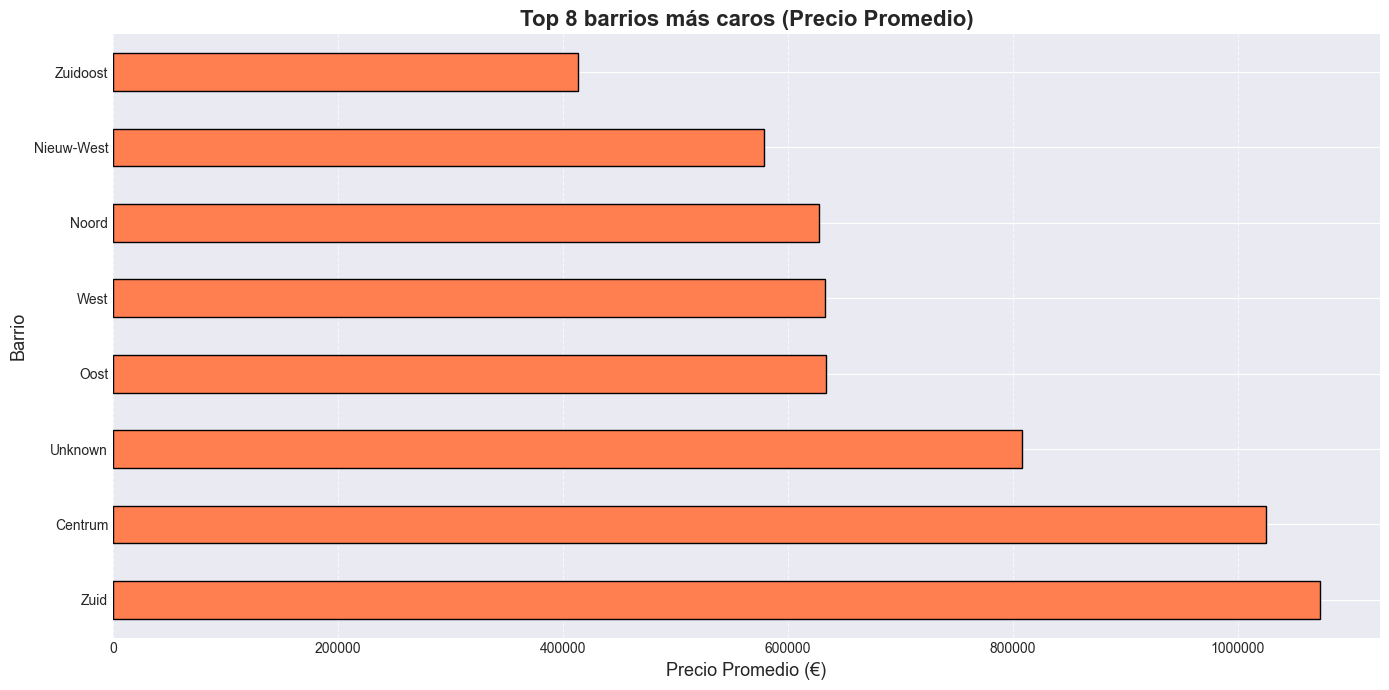

In [33]:
# Gráfico de barras ordenado por precio promedio (Top 8)
if 'neighborhood' in df.columns:
    neighborhood_avg_price = df.groupby('neighborhood')['price'].mean().sort_values(ascending=False).head(8)

    plt.figure(figsize=(14, 7))
    neighborhood_avg_price.plot(kind='barh', color='coral', edgecolor='black')
    plt.title('Top 8 barrios más caros (Precio Promedio)', fontsize=16, fontweight='bold')
    plt.xlabel('Precio Promedio (€)', fontsize=13)
    plt.ylabel('Barrio', fontsize=13)
    plt.ticklabel_format(style='plain', axis='x')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### 4.10 Energy Label (Encoding Ordinal)

In [34]:
# Análisis Energy Label
if 'energy_label' in df.columns:
    print("DISTRIBUCIÓN DE ENERGY LABEL")
    print(df['energy_label'].value_counts())

    # Ordinal encoding usando el mapping de MLConfig
    energy_mapping = MLConfig.ENERGY_LABEL_MAPPING

    df['energy_label_encoded'] = df['energy_label'].map(energy_mapping).fillna(1).astype(int)
    print("\nOrdinal encoding aplicado (desde MLConfig):")
    print(df[['energy_label', 'energy_label_encoded']].drop_duplicates().sort_values('energy_label_encoded', ascending=False))
else:
    print("Variable 'energy_label' no encontrada")

DISTRIBUCIÓN DE ENERGY LABEL
energy_label
A      1693
C       863
A++     749
B       593
D       523
A+      379
E       170
F        78
G        61
         27
Name: count, dtype: int64

Ordinal encoding aplicado (desde MLConfig):
    energy_label  energy_label_encoded
32           A++                     7
7             A+                     6
0              A                     5
8              B                     4
2              C                     3
18             D                     2
26             E                     1
564                                  1
1              F                     0
335            G                     0


### 4.11 Year Built: Binning por décadas

In [35]:
# Year Built -> Binning por decadas
if 'year_built' in df.columns:
    df['year_built'] = pd.to_numeric(df['year_built'], errors='coerce')

    # Crear bins por décadas
    bins = [0, 1900, 1950, 1980, 2000, 2010, 2030]
    labels = ['Pre-1900', '1900-1950', '1950-1980', '1980-2000', '2000-2010', '2010+']
    df['year_built_category'] = pd.cut(df['year_built'], bins=bins, labels=labels, include_lowest=True)

    print("YEAR BUILT - Distribución por décadas:")
    print(df['year_built_category'].value_counts().sort_index())
else:
    print("Variable 'year_built' no encontrada")

YEAR BUILT - Distribución por décadas:
year_built_category
Pre-1900      535
1900-1950    1309
1950-1980     497
1980-2000     527
2000-2010     307
2010+        1298
Name: count, dtype: int64


### 4.11.1 Análisis Temporal

**Edad de la propiedad y Propiedades nuevas vs históricas**

Análisis de property_age

- Propiedades nuevas (≤5 años): 627 (12.2%)
- Propiedades históricas (<1950): 1834 (35.7%)

- Edad promedio: 64.5 años
- Edad mediana: 52.0 años

PRECIO POR GRUPO DE EDAD
                 price                 price_per_m2 energy_label
                  mean    median count         mean     <lambda>
property_age                                                    
0-5 años      744177.0  610000.0   211       8254.0          A++
6-10 años     849008.0  675000.0   587       8654.0          A++
11-20 años    820818.0  625000.0   299       7149.0            A
21-50 años    564316.0  495000.0   702       6497.0            A
51-100 años   653531.0  495000.0   964       7694.0            C
>100 años     903991.0  615000.0  1172       9445.0            C


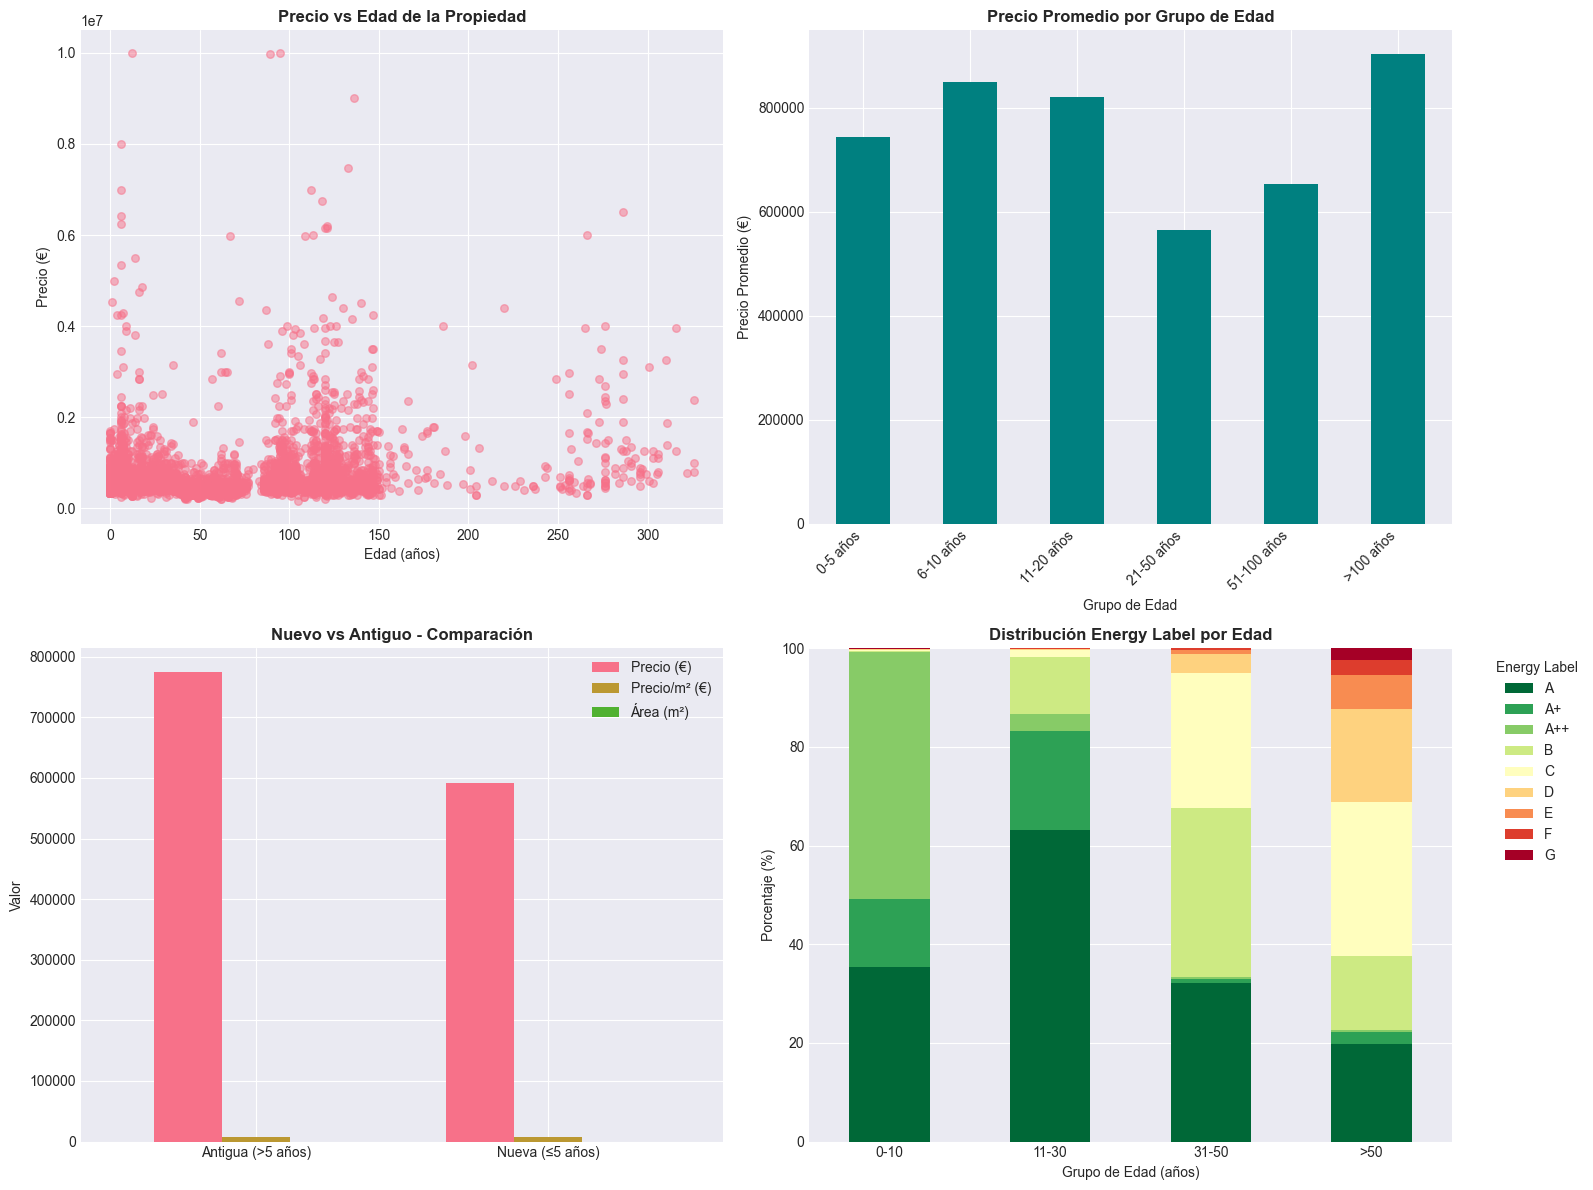

In [36]:
# Análisis de property_age
print("Análisis de property_age")

# Usar año de referencia desde MLConfig
current_year = MLConfig.CURRENT_YEAR

df_temp = df.copy()
df_temp['property_age'] = current_year - df_temp['year_built']
df_temp['is_new'] = (df_temp['property_age'] <= 5).astype(int)
df_temp['is_historic'] = (df_temp['year_built'] < 1950).astype(int)

print(f"\n- Propiedades nuevas (≤5 años): {df_temp['is_new'].sum()} ({df_temp['is_new'].mean()*100:.1f}%)")
print(f"- Propiedades históricas (<1950): {df_temp['is_historic'].sum()} ({df_temp['is_historic'].mean()*100:.1f}%)")
print(f"\n- Edad promedio: {df_temp['property_age'].mean():.1f} años")
print(f"- Edad mediana: {df_temp['property_age'].median():.1f} años")

# Relación edad vs precio
age_groups = pd.cut(df_temp['property_age'], bins=[0, 5, 10, 20, 50, 100, 200], 
    labels=['0-5 años', '6-10 años', '11-20 años', '21-50 años', '51-100 años', '>100 años'])

# Crear price_per_m2 temporal si no existe
if 'price_per_m2' not in df_temp.columns and 'living_area' in df_temp.columns:
    df_temp['price_per_m2'] = df_temp['price'] / df_temp['living_area']

age_analysis = df_temp.groupby(age_groups).agg({
    'price': ['mean', 'median', 'count'],
    'price_per_m2': 'mean',
    'energy_label': lambda x: x.mode()[0] if len(x.mode()) > 0 else None
}).round(0)

print("\nPRECIO POR GRUPO DE EDAD")
print(age_analysis)

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].scatter(df_temp['property_age'], df_temp['price'], alpha=0.5, s=30)
axes[0, 0].set_title('Precio vs Edad de la Propiedad', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Edad (años)')
axes[0, 0].set_ylabel('Precio (€)')

age_analysis[('price', 'mean')].plot(kind='bar', ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Precio Promedio por Grupo de Edad', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Precio Promedio (€)')
axes[0, 1].set_xlabel('Grupo de Edad')
axes[0, 1].set_xticklabels(age_analysis.index, rotation=45, ha='right')

comparison = df_temp.groupby('is_new').agg({
    'price': 'mean',
    'price_per_m2': 'mean',
    'living_area': 'mean'
})
comparison.index = ['Antigua (>5 años)', 'Nueva (≤5 años)']
comparison.plot(kind='bar', ax=axes[1, 0], width=0.7)
axes[1, 0].set_title('Nuevo vs Antiguo - Comparación', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Valor')
axes[1, 0].legend(['Precio (€)', 'Precio/m² (€)', 'Área (m²)'])
axes[1, 0].set_xticklabels(comparison.index, rotation=0)

if 'energy_label' in df_temp.columns:
    age_bins = pd.cut(df_temp['property_age'], bins=[0, 10, 30, 50, 200], labels=['0-10', '11-30', '31-50', '>50'])
    energy_age = pd.crosstab(age_bins, df_temp['energy_label'], normalize='index') * 100
    energy_age.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='RdYlGn_r')
    axes[1, 1].set_title('Distribución Energy Label por Edad', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Porcentaje (%)')
    axes[1, 1].set_xlabel('Grupo de Edad (años)')
    axes[1, 1].legend(title='Energy Label', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1, 1].set_xticklabels(energy_age.index, rotation=0)

plt.tight_layout()
plt.show()

### 4.12 Análisis Geoespacial con Mapas

In [37]:
# Filtrar datos con coordenadas válidas
df_geo = df[df['latitude'].notna() & df['longitude'].notna()].copy()

print("DATOS GEOESPACIALES")
print(f"- Total propiedades con coordenadas: {len(df_geo)} ({len(df_geo)/len(df)*100:.1f}%)")
print(f"- Latitud rango: {df_geo['latitude'].min():.4f} a {df_geo['latitude'].max():.4f}")
print(f"- Longitud rango: {df_geo['longitude'].min():.4f} a {df_geo['longitude'].max():.4f}")

# Centro de Amsterdam
center_lat = df_geo['latitude'].median()
center_lon = df_geo['longitude'].median()

print(f"\nCentro del mapa: ({center_lat:.4f}, {center_lon:.4f})")

DATOS GEOESPACIALES
- Total propiedades con coordenadas: 4094 (79.7%)
- Latitud rango: 52.2896 a 52.4251
- Longitud rango: 4.7628 a 5.0286

Centro del mapa: (52.3619, 4.8869)


In [38]:
# MAPA 1: Scatter con precios (tamaño = precio, color = precio/m²)
map_prices = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='OpenStreetMap')

# Categorizar precio/m² en cuartiles para colores
df_geo['price_m2_quartile'] = pd.qcut(df_geo['price_per_m2'], q=4, labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto'])

color_map = {'Bajo': 'blue', 'Medio-Bajo': 'green', 'Medio-Alto': 'orange', 'Alto': 'red'}

# Añadir marcadores (sample 100 para evitar saturar el mapa)
sample_size = min(100, len(df_geo))
df_sample = df_geo.sample(n=sample_size, random_state=42)

for idx, row in df_sample.iterrows():
    folium.CircleMarker(
    location=[row['latitude'], row['longitude']],
    radius=row['price'] / 100000,
    color=color_map.get(row['price_m2_quartile'], 'gray'),
    fill=True,
    fillColor=color_map.get(row['price_m2_quartile'], 'gray'),
    fillOpacity=0.6,
    popup=f"""<b>Precio:</b> €{row['price']:,.0f}<br>
    <b>Precio/m²:</b> €{row['price_per_m2']:,.0f}<br>
    <b>Área:</b> {row['living_area']:.0f} m²<br>
    <b>Barrio:</b> {row['neighborhood']}"""
    ).add_to(map_prices)

# Leyenda
legend_html = '''
<div style="position: fixed; top: 10px; right: 10px; width: 180px; height: 140px; 
    background-color: white; border:2px solid grey; z-index:9999; font-size:14px;
    padding: 10px">
<b>Precio por m²</b><br>
<i class="fa fa-circle" style="color:blue"></i> Bajo<br>
<i class="fa fa-circle" style="color:green"></i> Medio-Bajo<br>
<i class="fa fa-circle" style="color:orange"></i> Medio-Alto<br>
<i class="fa fa-circle" style="color:red"></i> Alto<br>
<br><b>Tamaño:</b> ∝ Precio total
</div>
'''
map_prices.get_root().html.add_child(folium.Element(legend_html))

print("\n MAPA: Precios por ubicación (muestra de 100 propiedades)")
print(" Tamaño del círculo = Precio total")
print(" Color = Rango de precio/m²")

map_prices


 MAPA: Precios por ubicación (muestra de 100 propiedades)
 Tamaño del círculo = Precio total
 Color = Rango de precio/m²


In [39]:
# MAPA: Heatmap de densidad de propiedades
map_heatmap = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='CartoDB positron')

# Preparar datos para heatmap
heat_data = [[row['latitude'], row['longitude'], row['price']/1000000] for idx, row in df_geo.iterrows()]

HeatMap(heat_data, radius=15, blur=25, max_zoom=13).add_to(map_heatmap)

print("\n MAPA: Heatmap de densidad (intensidad = precio)")
print(f" {len(heat_data)} propiedades visualizadas")

map_heatmap


 MAPA: Heatmap de densidad (intensidad = precio)
 4094 propiedades visualizadas


CLUSTERING GEOGRÁFICO (5 zonas)
             Precio_Medio  Precio_m²  Área_Media Barrio_Principal  \
geo_cluster                                                         
2               2771400.0    15267.0       172.0             Zuid   
0                785201.0     9039.0        87.0             Zuid   
4                700670.0     7049.0       101.0            Noord   
3                559827.0     6133.0        94.0       Nieuw-West   
1                541632.0     5417.0        99.0         Zuidoost   

             N_Propiedades  
geo_cluster                 
2                      155  
0                     2216  
4                      636  
3                      649  
1                      405  


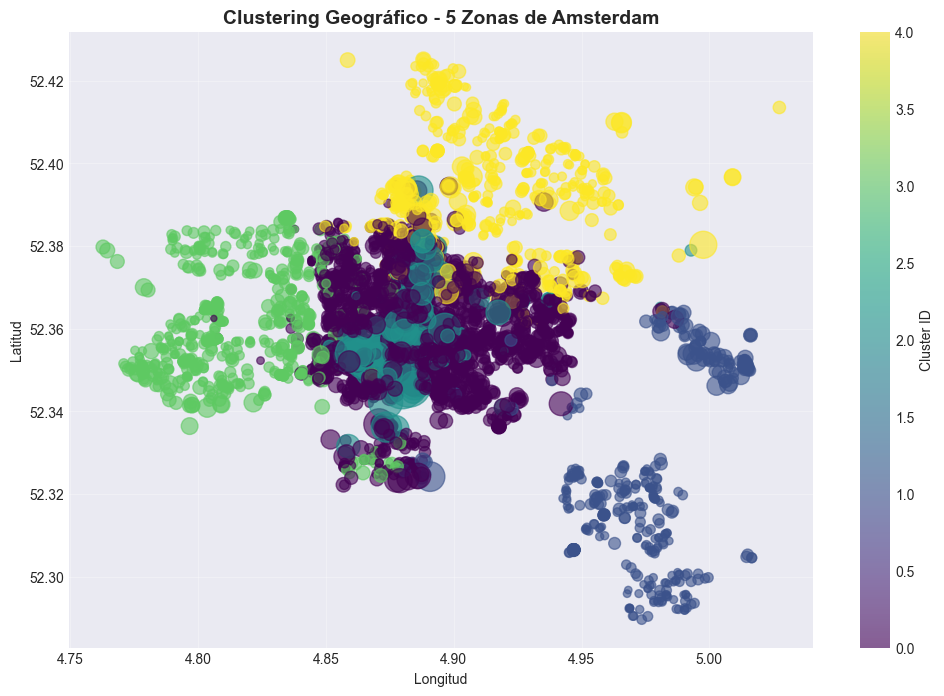

In [40]:
# ANÁLISIS: Clustering geográfico de precios
from sklearn.cluster import KMeans

# K-means en coordenadas geográficas
X_geo = df_geo[['latitude', 'longitude', 'price_per_m2']].dropna()

df_geo = df_geo.loc[X_geo.index].copy()

# Normalizar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_geo)

# Clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_geo['geo_cluster'] = kmeans.fit_predict(X_scaled)

print(f"CLUSTERING GEOGRÁFICO ({n_clusters} zonas)")

cluster_analysis = df_geo.groupby('geo_cluster').agg({
    'price': 'mean',
    'price_per_m2': 'mean',
    'living_area': 'mean',
    'neighborhood': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Mixed',
    'latitude': 'count'
}).round(0)

cluster_analysis.columns = ['Precio_Medio', 'Precio_m²', 'Área_Media', 'Barrio_Principal', 'N_Propiedades']
cluster_analysis = cluster_analysis.sort_values('Precio_Medio', ascending=False)

print(cluster_analysis)

# Visualizar clusters
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_geo['longitude'], df_geo['latitude'], 
    c=df_geo['geo_cluster'], cmap='viridis', 
    s=df_geo['price']/10000, alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title(f'Clustering Geográfico - {n_clusters} Zonas de Amsterdam', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

---

## 5. Análisis Bivariado

**Relaciones entre variables independientes y variable objetivo**

### 5.1 Price vs Living Area

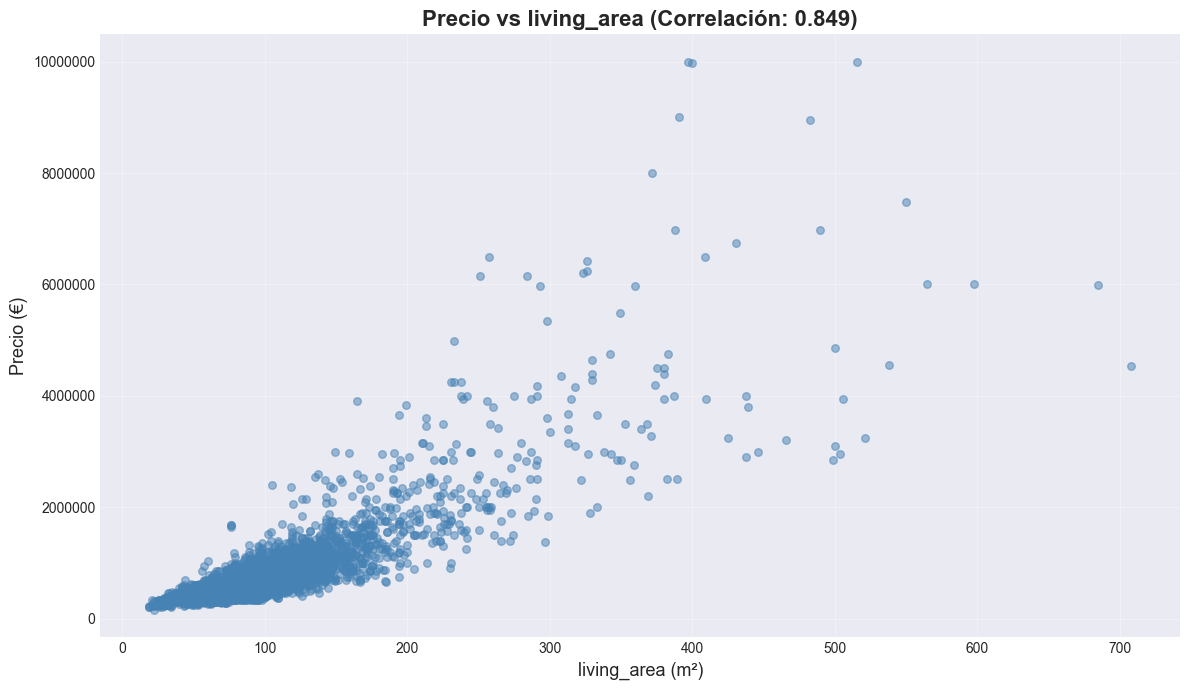

Correlación price vs living_area: 0.8488


In [41]:
# Scatter plot con correlación
area_col = 'living_area' if 'living_area' in df.columns else 'area'

if area_col in df.columns:
    corr = df[['price', area_col]].corr().iloc[0, 1]

    plt.figure(figsize=(12, 7))
    plt.scatter(df[area_col], df['price'], alpha=0.5, s=30, color='steelblue')
    plt.xlabel(f'{area_col} (m²)', fontsize=13)
    plt.ylabel('Precio (€)', fontsize=13)
    plt.title(f'Precio vs {area_col} (Correlación: {corr:.3f})', fontsize=16, fontweight='bold')
    plt.ticklabel_format(style='plain', axis='y')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Correlación price vs {area_col}: {corr:.4f}")

### 5.2 Análisis de Precio por m²

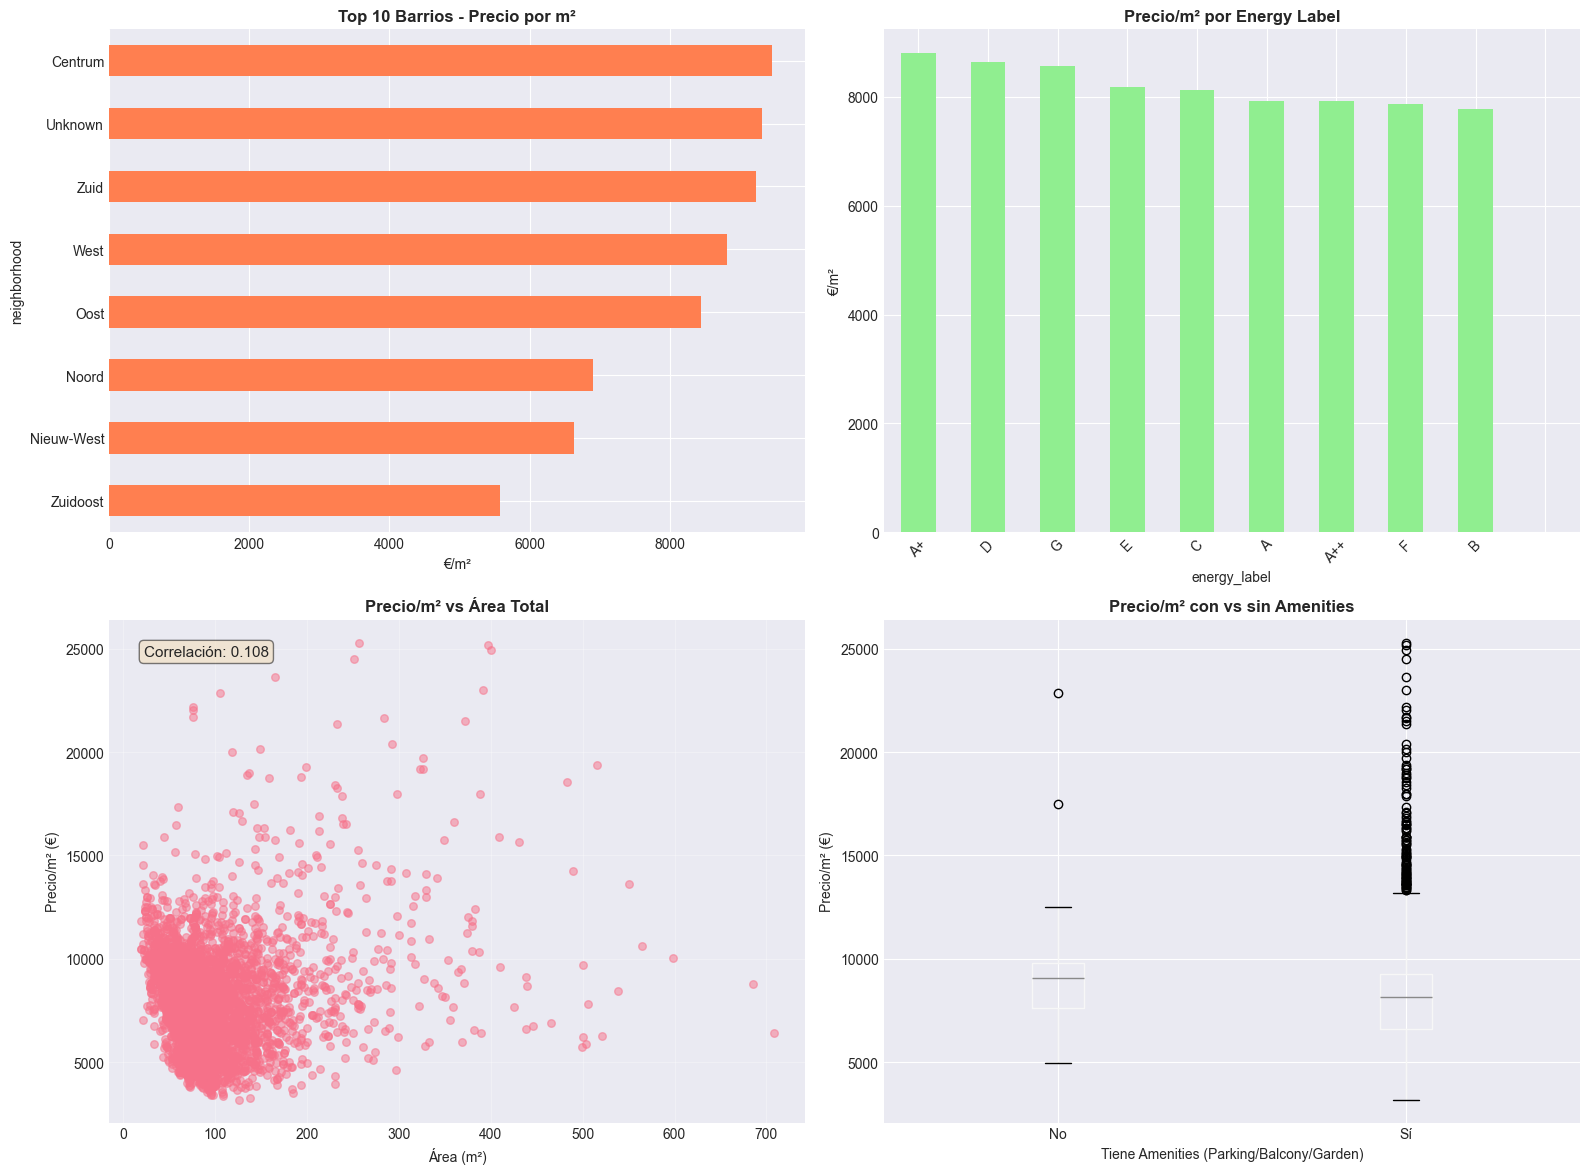

RESULTADOS de PRECIO POR M²
- Barrio más caro/m²: Centrum - €9,462/m²
- Barrio más económico/m²: Zuidoost - €5,572/m²

Correlación área vs precio/m²: 0.108
- Propiedades más grandes tienden a tener MAYOR precio/m²


In [42]:
# Análisis profundo de precio por m²
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Precio/m² por barrio (top 10)
top_neighborhoods = df.groupby('neighborhood')['price_per_m2'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)
top_neighborhoods['mean'].plot(kind='barh', ax=axes[0, 0], color='coral')
axes[0, 0].set_title('Top 10 Barrios - Precio por m²', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('€/m²')
axes[0, 0].invert_yaxis()

# 2. Precio/m² por energy label
if 'energy_label' in df.columns:
    energy_price_m2 = df.groupby('energy_label')['price_per_m2'].mean().sort_values(ascending=False)
    energy_price_m2.plot(kind='bar', ax=axes[0, 1], color='lightgreen')
    axes[0, 1].set_title('Precio/m² por Energy Label', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('€/m²')
    axes[0, 1].set_xticklabels(energy_price_m2.index, rotation=45)

# 3. Precio/m² vs Área (scatter)
axes[1, 0].scatter(df['living_area'], df['price_per_m2'], alpha=0.5, s=30)
axes[1, 0].set_title('Precio/m² vs Área Total', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Área (m²)')
axes[1, 0].set_ylabel('Precio/m² (€)')
axes[1, 0].grid(True, alpha=0.3)

# Correlación
corr = df[['living_area', 'price_per_m2']].corr().iloc[0, 1]
axes[1, 0].text(0.05, 0.95, f'Correlación: {corr:.3f}', 
    transform=axes[1, 0].transAxes, fontsize=11, 
    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Distribución precio/m² con amenities
df['has_amenities'] = ((df['has_parking'] == 1) | (df['has_balcony'] == 1) | (df['has_garden'] == 1)).astype(int)
df.boxplot(column='price_per_m2', by='has_amenities', ax=axes[1, 1])
axes[1, 1].set_title('Precio/m² con vs sin Amenities', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tiene Amenities (Parking/Balcony/Garden)')
axes[1, 1].set_ylabel('Precio/m² (€)')
axes[1, 1].set_xticklabels(['No', 'Sí'])
plt.suptitle('')

plt.tight_layout()
plt.show()

print("RESULTADOS de PRECIO POR M²")
print(f"- Barrio más caro/m²: {top_neighborhoods.index[0]} - €{top_neighborhoods['mean'].iloc[0]:,.0f}/m²")
print(f"- Barrio más económico/m²: {top_neighborhoods.index[-1]} - €{top_neighborhoods['mean'].iloc[-1]:,.0f}/m²")
print(f"\nCorrelación área vs precio/m²: {corr:.3f}")
if corr < 0:
    print("- Propiedades más grandes tienden a tener MENOR precio/m² (economías de escala)")
else:
    print("- Propiedades más grandes tienden a tener MAYOR precio/m²")

### 5.3 Scatter Matrix

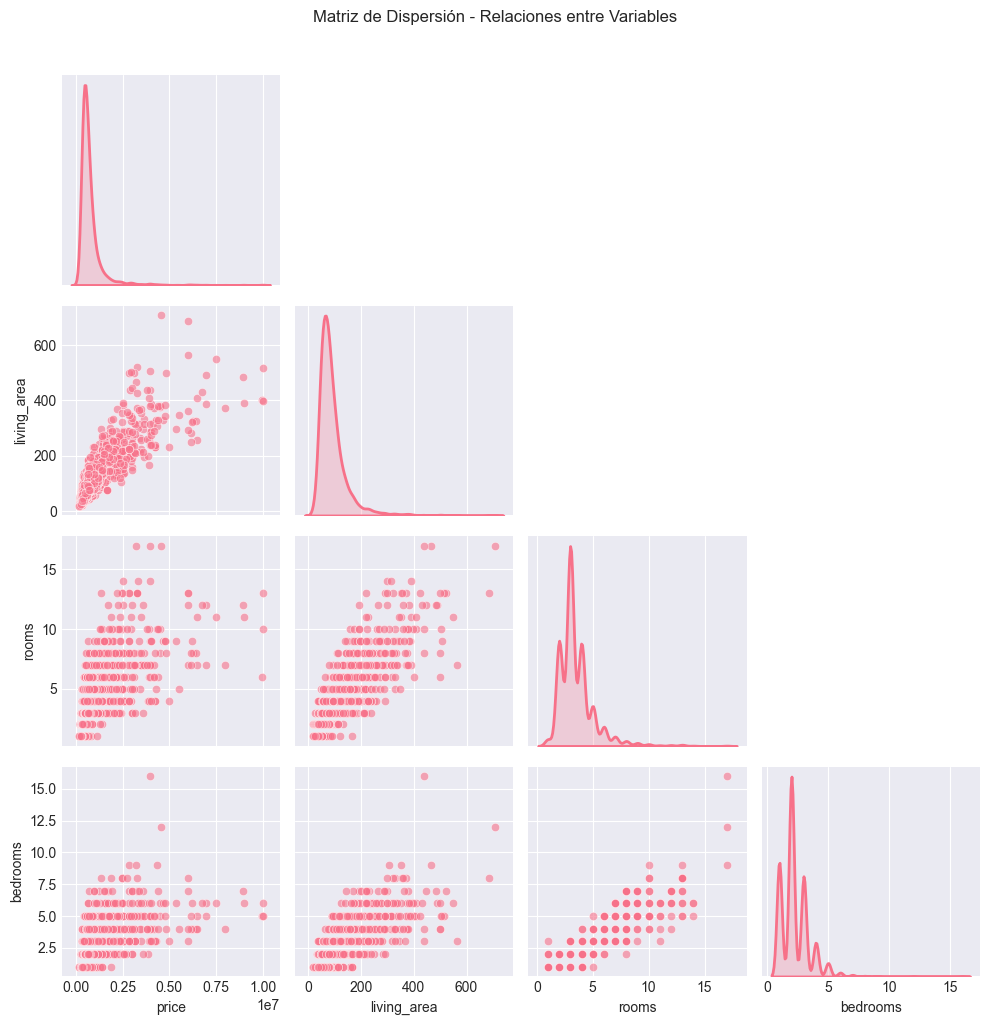

In [43]:
# Scatter matrix de variables relevantes
key_vars = ['price', 'living_area', 'rooms', 'bedrooms']
available = [v for v in key_vars if v in df.columns]

if len(available) >= 3:
    eda.plot_scatter_matrix(available[:4])

### 5.4 Comparación de Variables Categóricas

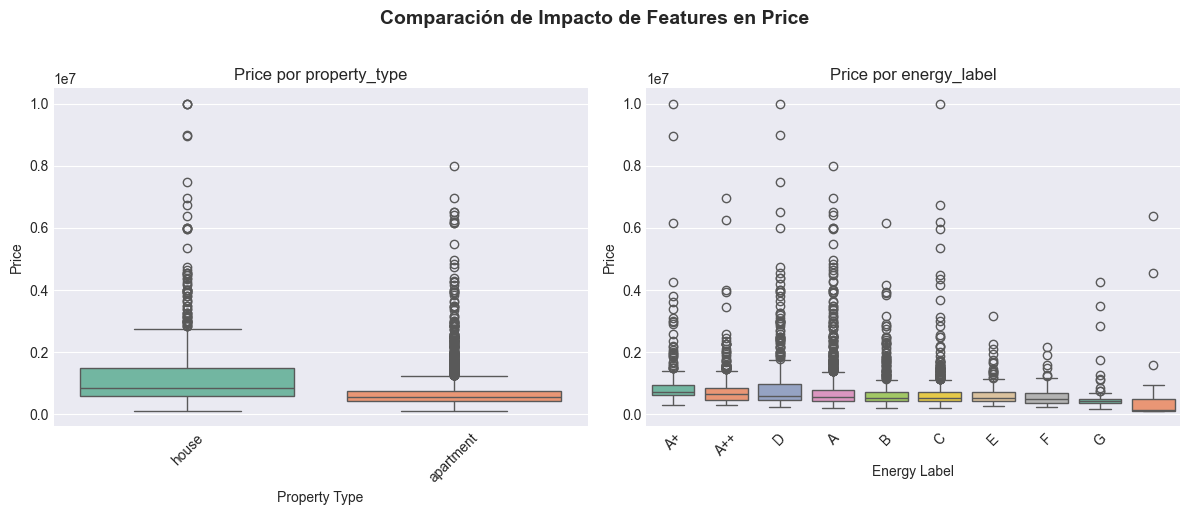

In [44]:
# Comparación del impacto de múltiples variables categóricas
categorical_features = ['property_type', 'energy_label']
available = [f for f in categorical_features if f in df.columns]

if len(available) >= 2:
    eda.plot_feature_comparison(available, target='price')

### 5.5 Precio vs Rooms

INFO 2026-05-12 12:56:24,165 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO 2026-05-12 12:56:24,305 category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


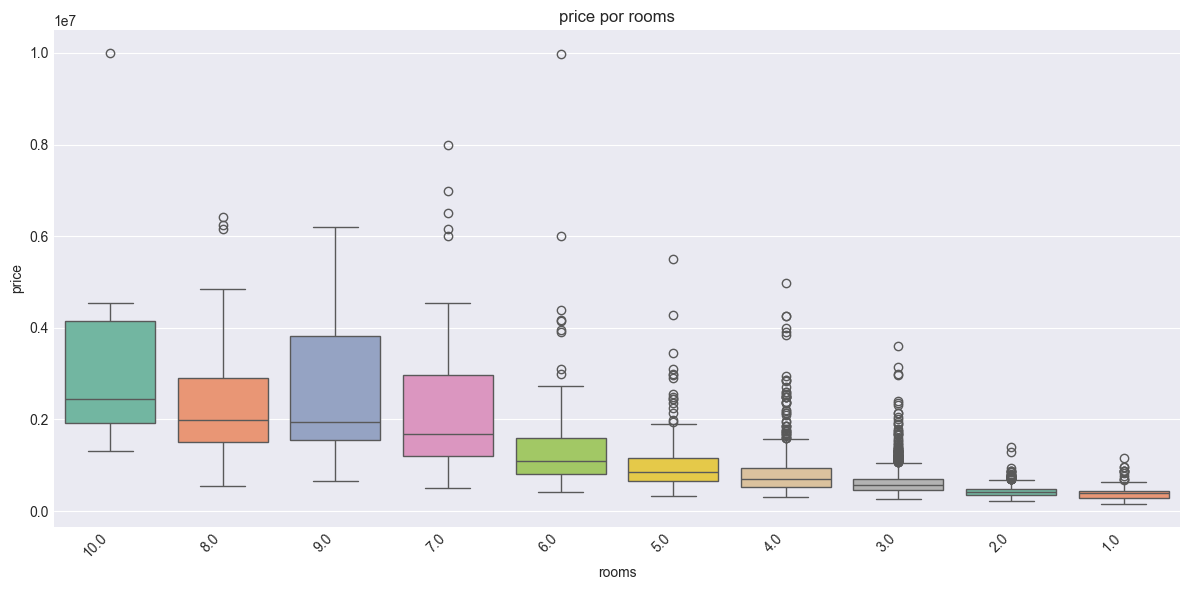

In [45]:
# Diagrama de cajas price por rooms
if 'rooms' in df.columns:
    eda.plot_boxplot_by_category('rooms', 'price', top_n=10)

### 5.6 Análisis de Impacto de Parking

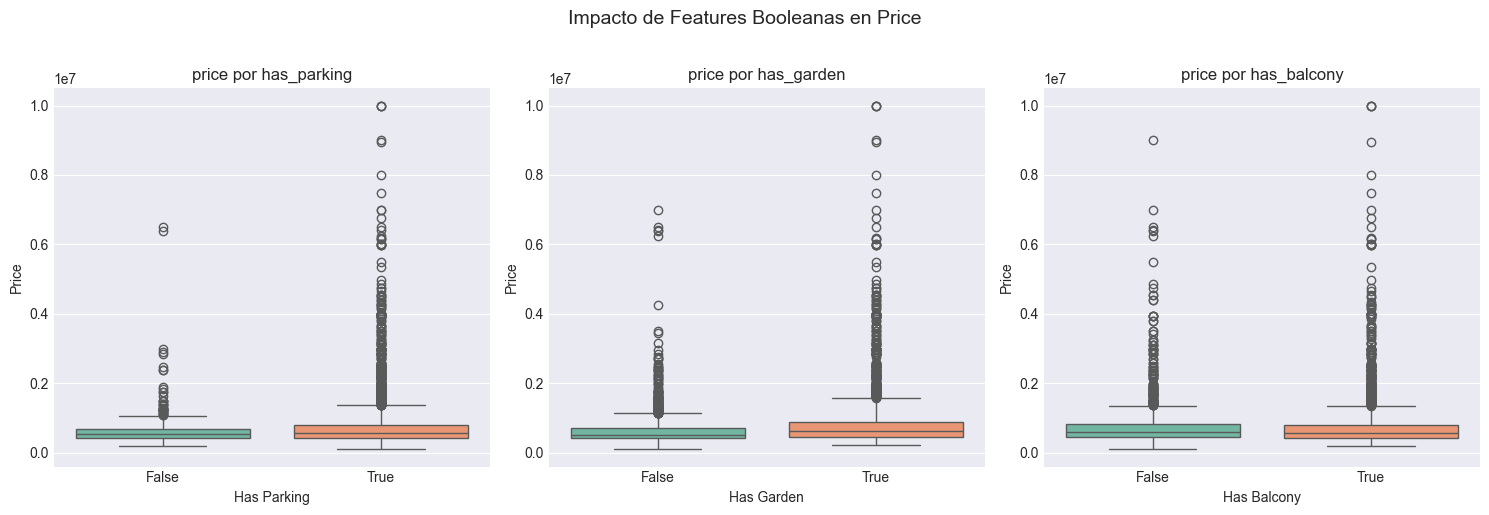

Análisis del impacto del parking
- SIN parking: 440 propiedades (mediana: €549,000)
- CON parking: 4696 properties (mediana: €575,000)
- Incremento del precio: €26,000 (4.7%)


In [46]:
# Análisis del impacto de amenities en el precio
if 'has_parking' in df.columns:
    # Comparar impacto de múltiples amenities simultáneamente
    amenities = ['has_parking', 'has_garden', 'has_balcony']
    available_amenities = [a for a in amenities if a in df.columns]
    
    if available_amenities:
        eda.plot_boolean_boxplots(available_amenities, 'price')
    
    # Estadísticas detalladas de parking
    print("Análisis del impacto del parking")
    count_no_parking = (df['has_parking'] == False).sum()
    count_parking = (df['has_parking'] == True).sum()
    median_no = df[df['has_parking'] == False]['price'].median()
    median_yes = df[df['has_parking'] == True]['price'].median()
    
    print(f"- SIN parking: {count_no_parking} propiedades (mediana: €{median_no:,.0f})")
    print(f"- CON parking: {count_parking} properties (mediana: €{median_yes:,.0f})")
    print(f"- Incremento del precio: €{median_yes - median_no:,.0f} ({(median_yes/median_no - 1)*100:.1f}%)")

### 5.7 Análisis de Impacto de Amenidades

Análisis de amenidades

ANÁLISIS DEL IMPACTO DE LAS AMENIDADES
     Amenity    % True  Count_0  Count_1   Avg_Price_0   Avg_Price_1        Diff_€    Diff_%
  has_garden 50.739875     2530     2606 625763.850988 876541.035687 250777.184699 40.075371
 has_parking 91.433022      440     4696 659568.034091 761762.893313 102194.859223 15.494210
is_furnished  6.152648     4820      316 750144.288589 796686.743671  46542.455082  6.204467
 has_balcony 72.040498     1436     3700 780069.112117 742505.199189 -37563.912928 -4.815460


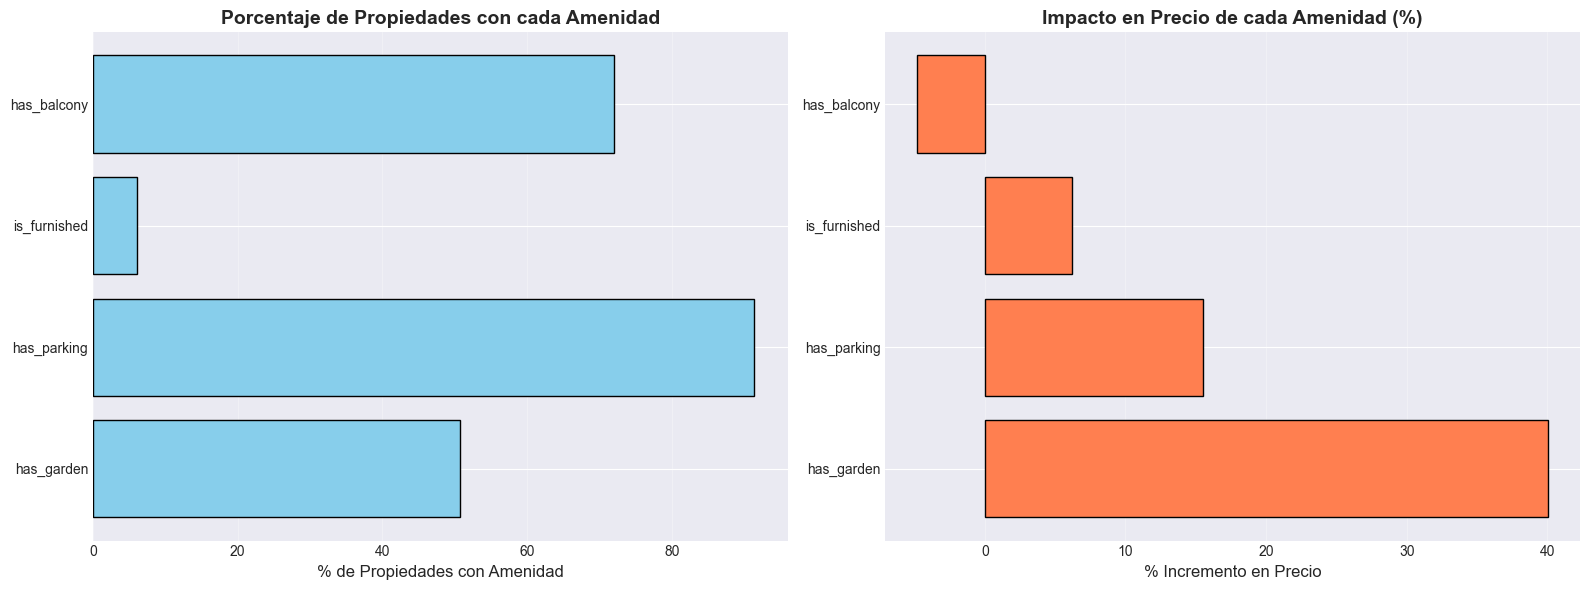

In [47]:
# Impacto de amenidades
print("Análisis de amenidades")

amenity_columns = ['has_balcony', 'has_garden', 'has_parking', 'is_furnished']
amenity_columns = [col for col in amenity_columns if col in df.columns]

if len(amenity_columns) > 0:
    results = []
    
    for col in amenity_columns:
        count_0 = (df[col] == False).sum()
        count_1 = (df[col] == True).sum()
        avg_price_0 = df[df[col] == False]['price'].mean()
        avg_price_1 = df[df[col] == True]['price'].mean()
        difference = avg_price_1 - avg_price_0
        
        if avg_price_0 != 0:
            percentage_diff = (difference / avg_price_0) * 100
        else:
            percentage_diff = 0
        
        percentage_true = (count_1 / (count_0 + count_1)) * 100 if (count_0 + count_1) > 0 else 0
        
        results.append({
            'Amenity': col,
            '% True': percentage_true,
            'Count_0': count_0,
            'Count_1': count_1,
            'Avg_Price_0': avg_price_0,
            'Avg_Price_1': avg_price_1,
            'Diff_€': difference,
            'Diff_%': percentage_diff
        })
    
    results_df = pd.DataFrame(results).sort_values('Diff_%', ascending=False)
    
    print("\nANÁLISIS DEL IMPACTO DE LAS AMENIDADES")
    print(results_df.to_string(index=False))
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].barh(results_df['Amenity'], results_df['% True'], color='skyblue', edgecolor='black')
    axes[0].set_xlabel('% de Propiedades con Amenidad', fontsize=12)
    axes[0].set_title('Porcentaje de Propiedades con cada Amenidad', fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    axes[1].barh(results_df['Amenity'], results_df['Diff_%'], color='coral', edgecolor='black')
    axes[1].set_xlabel('% Incremento en Precio', fontsize=12)
    axes[1].set_title('Impacto en Precio de cada Amenidad (%)', fontsize=14, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No se encontraron columnas de amenidades booleanas")

### 5.8 Interacciones entre Amenities

Combinaciones de amenities

ANÁLISIS DE COMBINACIONES DE AMENITIES
                     Precio_Medio  Precio_Mediana  Cantidad  Precio_m²  \
amenity_combo_label                                                      
Parking + Garden         906660.0        675000.0       735     8039.0   
PREMIUM (Todo)           881252.0        625000.0      1658     8113.0   
Balcony + Garden         728729.0        610000.0       118     9037.0   
Solo Garden              701716.0        515000.0        88     8312.0   
Sin amenities            671088.0        570000.0        51     9138.0   
Solo Parking             635358.0        550000.0       531     8637.0   
Parking + Balcony        630341.0        515000.0      1746     7908.0   
Solo Balcony             560962.0        512000.0       172     7293.0   

                     Área_Media  
amenity_combo_label              
Parking + Garden          112.0  
PREMIUM (Todo)            102.0  
Balcony + Garden           80.0  
Solo Garden           

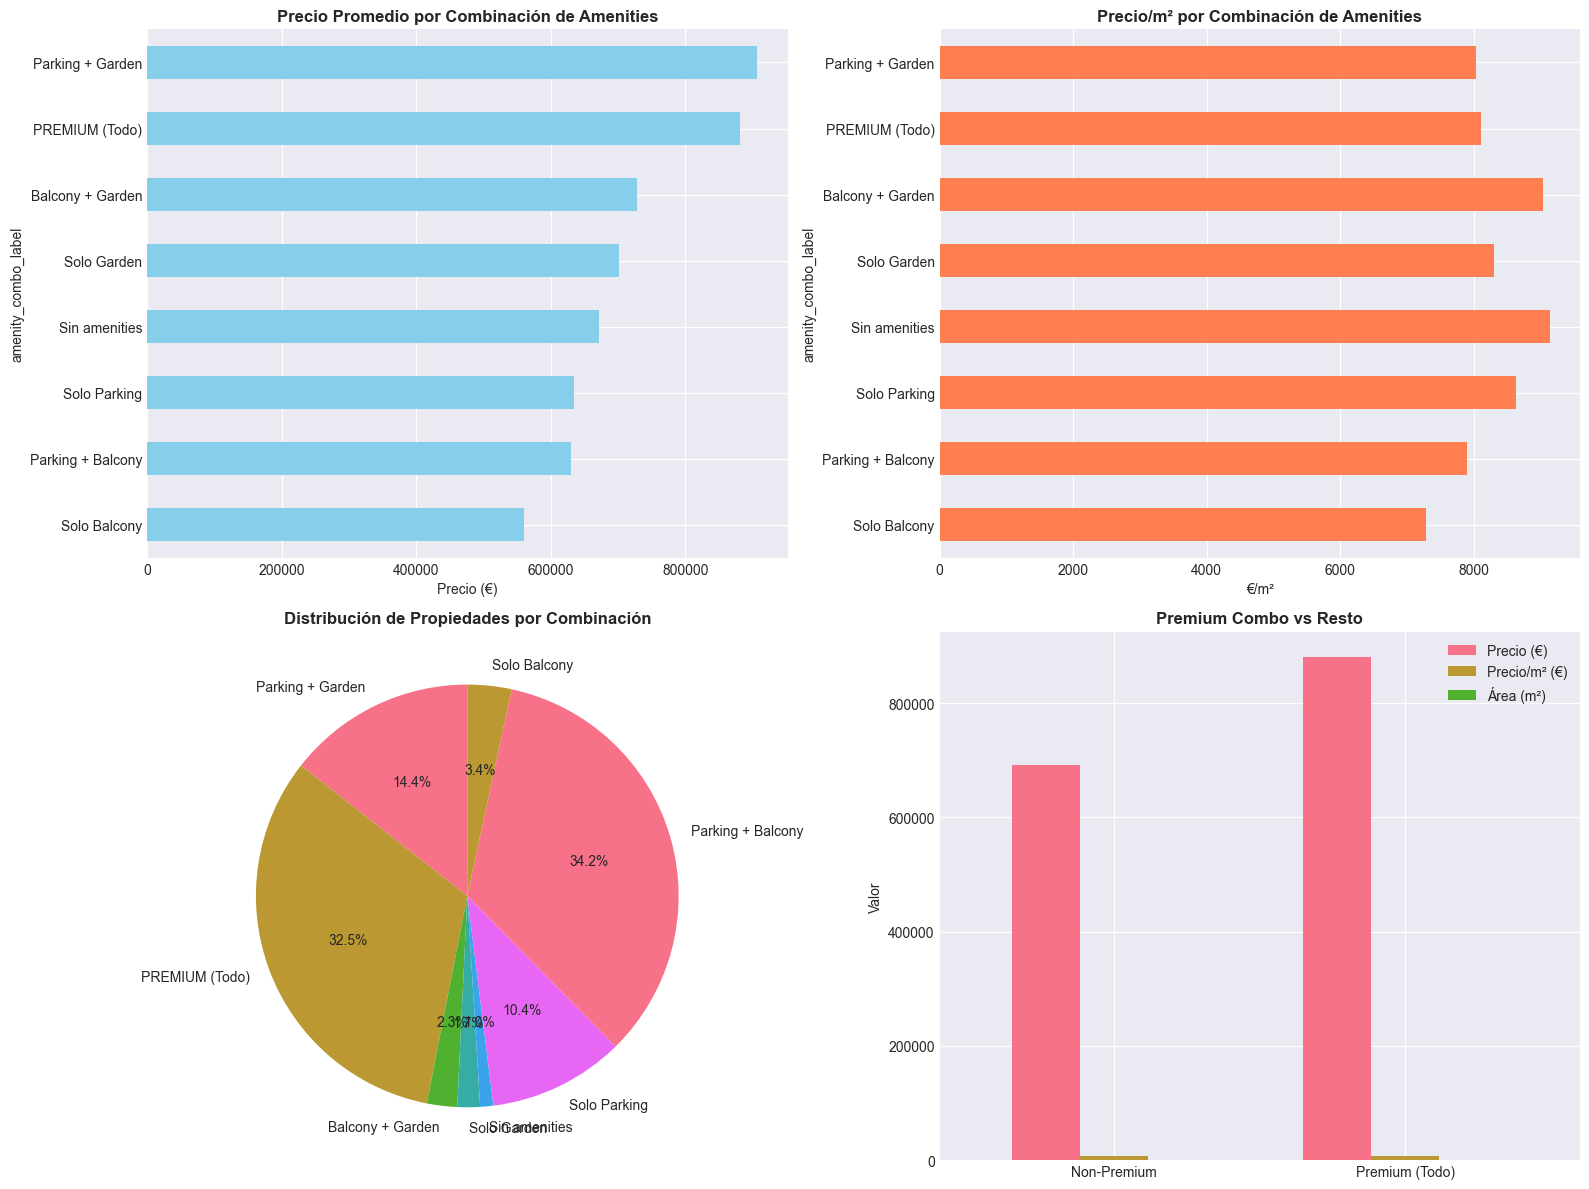


--------------------------------------------------------------------------------
EFECTO MULTIPLICATIVO DE AMENITIES
Precio sin amenities: €671,088
Precio con PREMIUM combo: €881,252

 -> PREMIUM COMBO aumenta precio en: 31.3%


In [48]:
print("Combinaciones de amenities")

df_temp = df.copy()

# Crear features de combinaciones de amenities
df_temp['premium_combo'] = (
    (df_temp['has_balcony'] == 1) & 
    (df_temp['has_garden'] == 1) & 
    (df_temp['has_parking'] == 1)
).astype(int)

df_temp['double_combo_balcony_parking'] = (
    (df_temp['has_balcony'] == 1) & (df_temp['has_parking'] == 1)
).astype(int)

df_temp['double_combo_garden_parking'] = (
    (df_temp['has_garden'] == 1) & (df_temp['has_parking'] == 1)
).astype(int)

# Análisis de todas las combinaciones posibles
df_temp['amenity_combination'] = (
    df_temp['has_parking'].fillna(0).astype(int).astype(str) + 
    df_temp['has_balcony'].fillna(0).astype(int).astype(str) + 
    df_temp['has_garden'].fillna(0).astype(int).astype(str)
)

# Mapear a labels
combo_labels = {
    '000': 'Sin amenities',
    '100': 'Solo Parking',
    '010': 'Solo Balcony',
    '001': 'Solo Garden',
    '110': 'Parking + Balcony',
    '101': 'Parking + Garden',
    '011': 'Balcony + Garden',
    '111': 'PREMIUM (Todo)'
}

df_temp['amenity_combo_label'] = df_temp['amenity_combination'].map(combo_labels)

# Filtrar datos válidos antes del análisis
df_valid = df_temp.dropna(subset=['price', 'price_per_m2', 'living_area', 'amenity_combo_label'])

# Análisis por combinación
if len(df_valid) > 0:
    combo_analysis = df_valid.groupby('amenity_combo_label').agg({
        'price': ['mean', 'median', 'count'],
        'price_per_m2': 'mean',
        'living_area': 'mean'
    }).round(0)

    combo_analysis.columns = ['Precio_Medio', 'Precio_Mediana', 'Cantidad', 'Precio_m²', 'Área_Media']
    combo_analysis = combo_analysis.sort_values('Precio_Medio', ascending=False)

    print("\nANÁLISIS DE COMBINACIONES DE AMENITIES")
    print(combo_analysis)

    # Visualización solo si hay datos
    if len(combo_analysis) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # 1. Precio promedio por combinación
        combo_analysis['Precio_Medio'].plot(kind='barh', ax=axes[0, 0], color='skyblue')
        axes[0, 0].set_title('Precio Promedio por Combinación de Amenities', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Precio (€)')
        axes[0, 0].invert_yaxis()

        # 2. Precio/m² por combinación
        combo_analysis['Precio_m²'].plot(kind='barh', ax=axes[0, 1], color='coral')
        axes[0, 1].set_title('Precio/m² por Combinación de Amenities', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('€/m²')
        axes[0, 1].invert_yaxis()

        # 3. Distribución de combinaciones
        combo_analysis['Cantidad'].plot(kind='pie', ax=axes[1, 0], autopct='%1.1f%%', startangle=90)
        axes[1, 0].set_title('Distribución de Propiedades por Combinación', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('')

        # 4. Premium vs Non-premium
        premium_comparison = df_valid.groupby('premium_combo').agg({
            'price': 'mean',
            'price_per_m2': 'mean',
            'living_area': 'mean'
        })
        premium_comparison.index = ['Non-Premium', 'Premium (Todo)']
        premium_comparison.plot(kind='bar', ax=axes[1, 1], width=0.7)
        axes[1, 1].set_title('Premium Combo vs Resto', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Valor')
        axes[1, 1].legend(['Precio (€)', 'Precio/m² (€)', 'Área (m²)'])
        axes[1, 1].set_xticklabels(premium_comparison.index, rotation=0)

        plt.tight_layout()
        plt.show()

        # Calcular efecto multiplicativo
        print("\n" + "-" * 80)
        print("EFECTO MULTIPLICATIVO DE AMENITIES")

        base_price = df_valid[df_valid['amenity_combo_label'] == 'Sin amenities']['price'].mean()
        premium_price = df_valid[df_valid['amenity_combo_label'] == 'PREMIUM (Todo)']['price'].mean()

        if pd.notna(base_price) and pd.notna(premium_price):
            premium_increase = ((premium_price - base_price) / base_price) * 100
            print(f"Precio sin amenities: €{base_price:,.0f}")
            print(f"Precio con PREMIUM combo: €{premium_price:,.0f}")
            print(f"\n -> PREMIUM COMBO aumenta precio en: {premium_increase:.1f}%")
    else:
        print("No hay datos para realizar el análisis de combinaciones")
else:
    print("No hay datos para analizar combinaciones de amenities")

### 5.9 Scatter Plot con Categorización

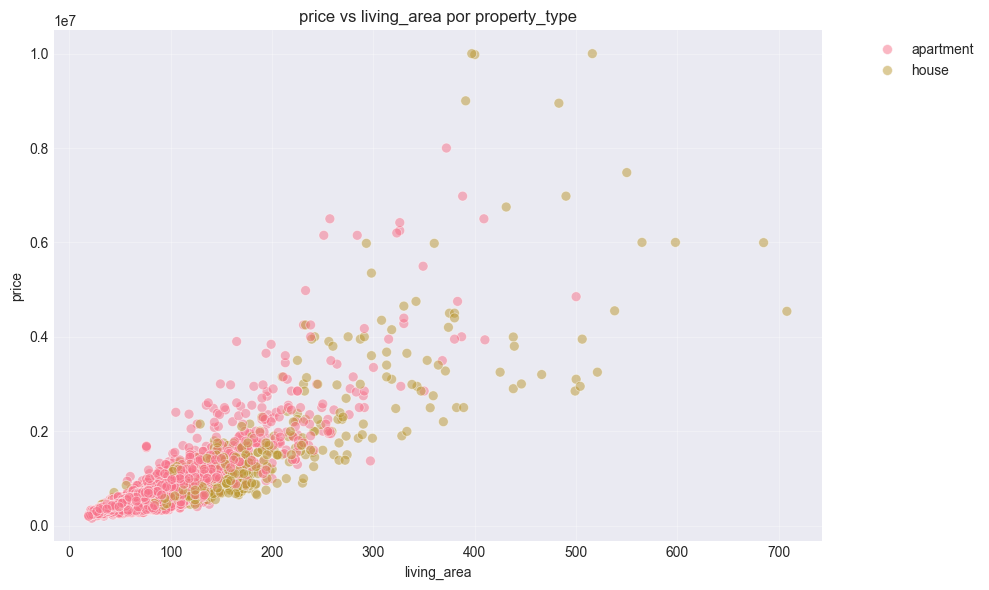

In [49]:
# Scatter plot de price vs living_area por property_type
if all(col in df.columns for col in ['living_area', 'price', 'property_type']):
    eda.plot_scatter('living_area', 'price', hue='property_type', alpha=0.5)

---

## 6. Feature Engineering

**Análisis exploratorio de features engineering -> Variables derivadas:** amenity score, ratios y clustering de códigos postales.


ANÁLISIS DE PRICE PER M²

Media: €  8,094.31 /m²
Mediana: €  8,148.15 /m²
Min: €  3,174.60 /m²
Max: € 25,291.83 /m²


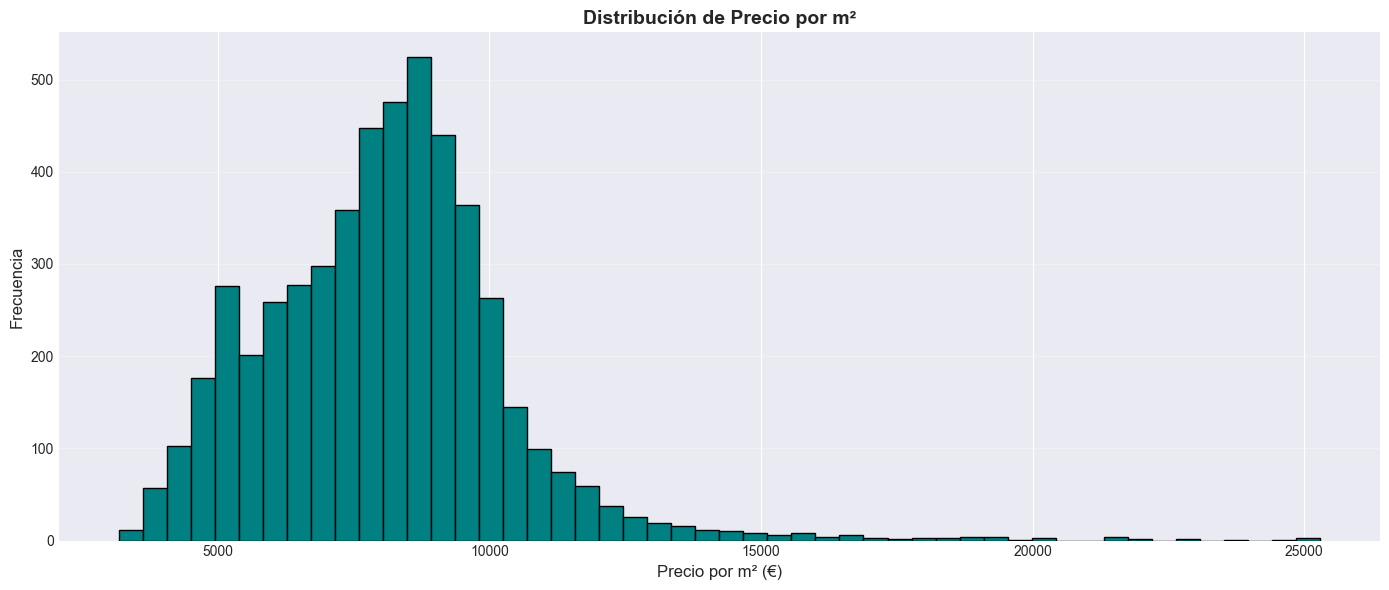

In [50]:
# Análisis de price_per_sqm
print("ANÁLISIS DE PRICE PER M²")

area_col = 'living_area' if 'living_area' in df.columns else 'area'

if area_col in df.columns:
    df_temp = df.copy()
    df_temp['price_per_sqm'] = df_temp['price'] / df_temp[area_col]

    print(f"\nMedia: €{df_temp['price_per_sqm'].mean():>10,.2f} /m²")
    print(f"Mediana: €{df_temp['price_per_sqm'].median():>10,.2f} /m²")
    print(f"Min: €{df_temp['price_per_sqm'].min():>10,.2f} /m²")
    print(f"Max: €{df_temp['price_per_sqm'].max():>10,.2f} /m²")

    # Distribución
    fig, axes = plt.subplots(figsize=(14, 6))

    axes.hist(df_temp['price_per_sqm'], bins=50, color='teal', edgecolor='black')
    axes.set_xlabel('Precio por m² (€)', fontsize=12)
    axes.set_ylabel('Frecuencia', fontsize=12)
    axes.set_title('Distribución de Precio por m²', fontsize=14, fontweight='bold')
    axes.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

### 6.1 Amenity Score

AMENITY SCORE
Score range: 0 - 4

Distribución:
amenity_score
0      55
1     769
2    2459
3    1781
4      72
Name: count, dtype: int64


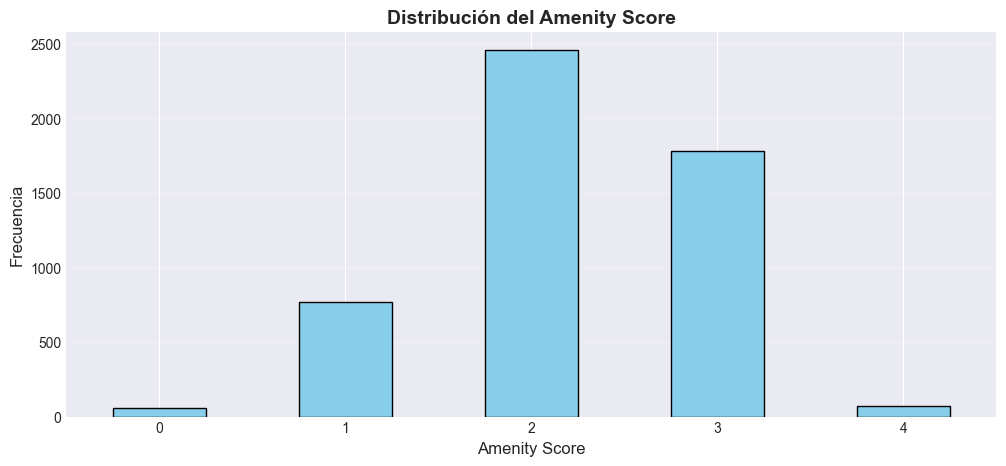

In [51]:
print("AMENITY SCORE")

amenities_cols = ['has_balcony', 'has_garden', 'is_furnished', 'has_parking']

df_temp = df.copy()
df_temp['amenity_score'] = 0
for col in amenities_cols:
    if col in df_temp.columns:
        df_temp['amenity_score'] += df_temp[col].fillna(0).astype(int)

print(f"Score range: {df_temp['amenity_score'].min()} - {df_temp['amenity_score'].max()}")
print(f"\nDistribución:")
print(df_temp['amenity_score'].value_counts().sort_index())

# Visualización
plt.figure(figsize=(12, 5))
df_temp['amenity_score'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribución del Amenity Score', fontsize=14, fontweight='bold')
plt.xlabel('Amenity Score', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

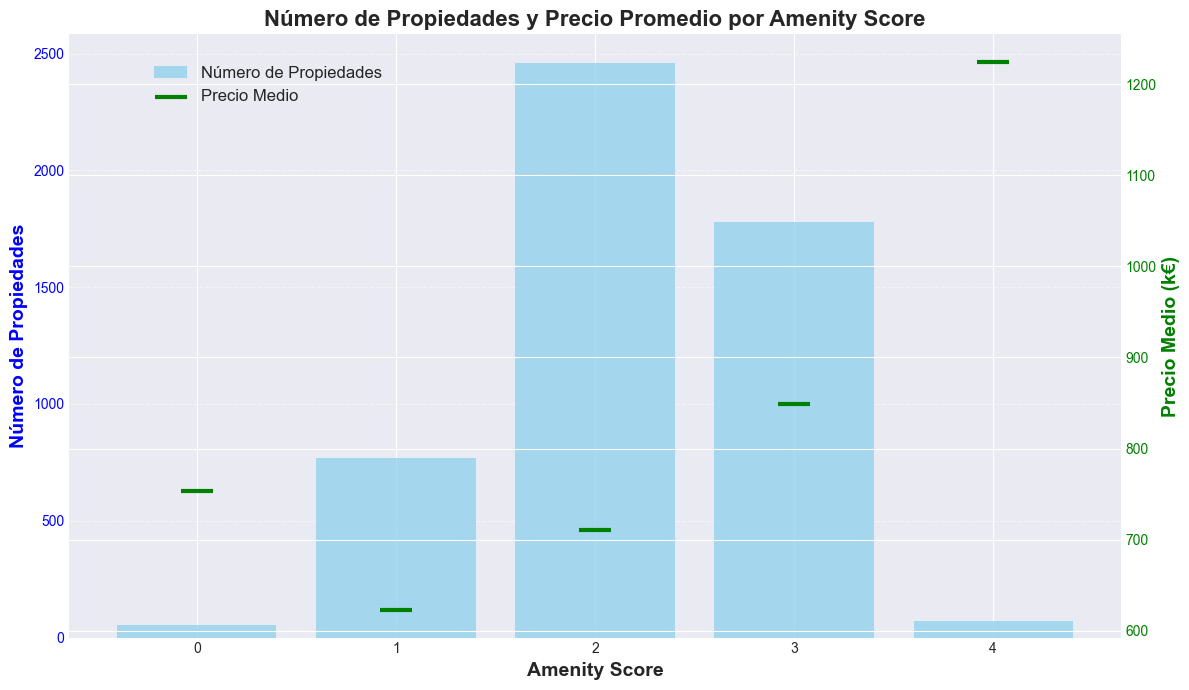

In [52]:
# Amenity Score vs Price
if 'amenity_score' in df_temp.columns:
    grouped = df_temp.groupby('amenity_score').agg({
    'price': ['count', 'mean']
    }).reset_index()
    grouped.columns = ['amenity_score', 'count', 'avg_price']
    grouped['avg_price_k'] = grouped['avg_price'] / 1000

    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Bar plot Count)
    ax1.bar(grouped['amenity_score'], grouped['count'], color='skyblue', label='Número de Propiedades', alpha=0.7)
    ax1.set_xlabel('Amenity Score', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Número de Propiedades', fontsize=14, color='blue', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_title('Número de Propiedades y Precio Promedio por Amenity Score', fontsize=16, fontweight='bold')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # Scatter plot (Avg Price)
    ax2 = ax1.twinx()
    ax2.scatter(grouped['amenity_score'], grouped['avg_price_k'], color='green', marker='_', s=500, label='Precio Medio', linewidths=3)
    ax2.set_ylabel('Precio Medio (k€)', fontsize=14, color='green', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='green')

    # Combinación de leyendas
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    fig.legend(handles1 + handles2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0.12, 0.92), fontsize=12)

    fig.tight_layout()
    plt.show()

### 6.2 Ratio Features

**Crear variables de ratios para capturar relaciones entre caracteristicas**

In [53]:
# Análisis de features de ratios
print("FEATURES DE RATIOS DEL MODELO")

df_temp = df.copy()
area_col = 'living_area' if 'living_area' in df_temp.columns else 'area'

# Features
if 'bedrooms' in df_temp.columns and 'rooms' in df_temp.columns:
    df_temp['bedroom_ratio'] = df_temp['bedrooms'] / df_temp['rooms']

if 'bathrooms' in df_temp.columns and 'rooms' in df_temp.columns:
    df_temp['bathroom_ratio'] = df_temp['bathrooms'] / df_temp['rooms']

if area_col in df_temp.columns and 'rooms' in df_temp.columns:
    df_temp['area_per_room'] = df_temp[area_col] / df_temp['rooms']

if area_col in df_temp.columns and 'bedrooms' in df_temp.columns:
    df_temp['area_per_bedroom'] = df_temp[area_col] / df_temp['bedrooms']

# Resúmen
model_ratio_features = ['bedroom_ratio', 'bathroom_ratio', 'area_per_room', 'area_per_bedroom']
existing_features = [f for f in model_ratio_features if f in df_temp.columns]

if len(existing_features) > 0:
    print("\n" + "-"*70)
    print(" FEATURES DE RATIOS - Estadísticas")
    print("-"*70)
    print(df_temp[existing_features].describe())
else:
    print("No se han podido crear features ratio")

FEATURES DE RATIOS DEL MODELO

----------------------------------------------------------------------
 FEATURES DE RATIOS - Estadísticas
----------------------------------------------------------------------
       bedroom_ratio  bathroom_ratio  area_per_room  area_per_bedroom
count    4909.000000     4335.000000    5099.000000       4898.000000
mean        0.638856        0.376565      26.670711         42.249519
std         0.128971        0.149482       9.672393         14.878994
min         0.200000        0.076923       8.666667         13.000000
25%         0.500000        0.250000      21.414286         32.500000
50%         0.666667        0.333333      25.000000         39.000000
75%         0.714286        0.500000      29.500000         49.000000
max         3.000000        1.000000     165.000000        188.333333


### 6.3 Features espaciales: distance_to_center_km, is_central

FEATURES ESPACIALES
Distancia promedio al centro: 3.64 km
Distancia mediana: 3.12 km

Propiedades centrales (<2km): 967 (18.8%)


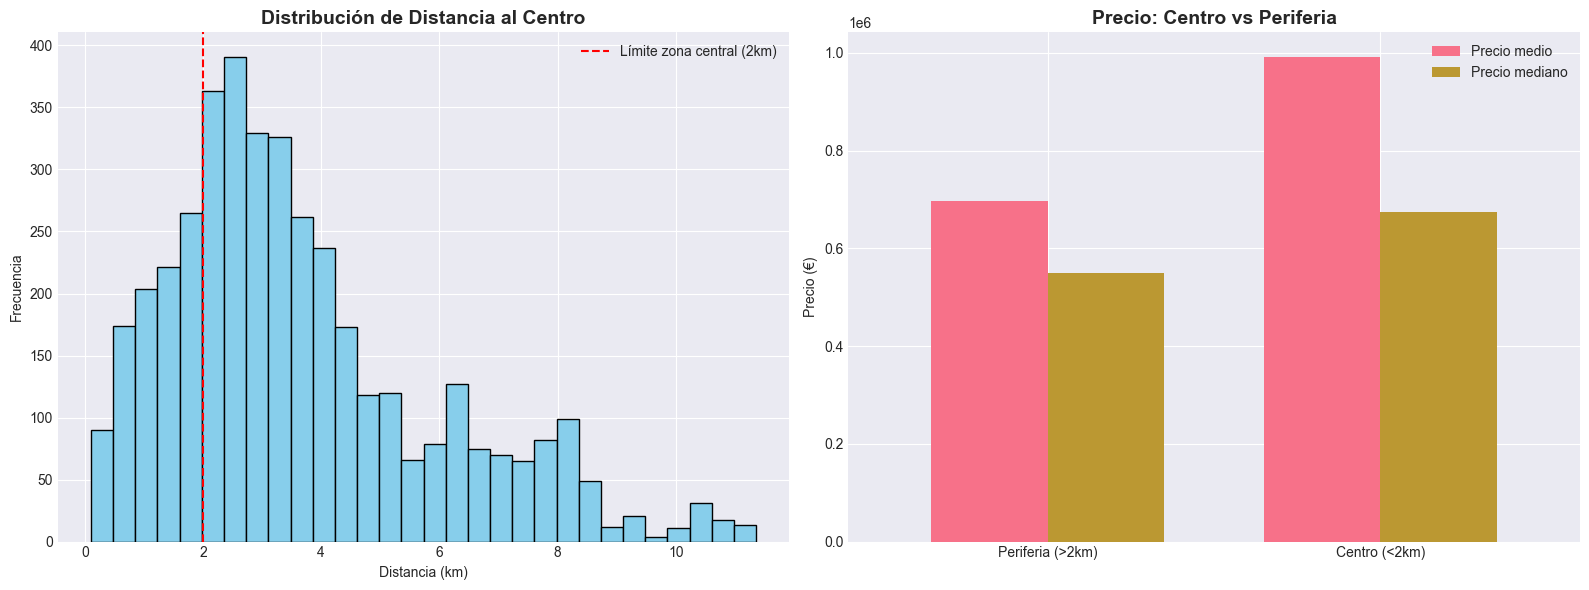

In [54]:
# Features espaciales (distance_to_center_km, is_central)
print("FEATURES ESPACIALES")

df_with_coords = df[['latitude', 'longitude']].copy()

if 'df_with_coords' in dir() and not df_with_coords['latitude'].isna().all():
    df_temp = df.copy()
    df_temp['latitude'] = df_with_coords['latitude']
    df_temp['longitude'] = df_with_coords['longitude']
    
    # Dam Square (centro de Amsterdam)
    DAM_SQUARE_LAT = 52.373057
    DAM_SQUARE_LON = 4.892557
    
    # Calcular distancia (Haversine)
    from math import radians, sin, cos, sqrt, atan2
    
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371  # Radio de la Tierra en km
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        return R * c
    
    df_temp['distance_to_center_km'] = df_temp.apply(
        lambda row: haversine(row['latitude'], row['longitude'], DAM_SQUARE_LAT, DAM_SQUARE_LON),
        axis=1
    )
    
    df_temp['is_central'] = (df_temp['distance_to_center_km'] < 2).astype(int)
    
    print(f"Distancia promedio al centro: {df_temp['distance_to_center_km'].mean():.2f} km")
    print(f"Distancia mediana: {df_temp['distance_to_center_km'].median():.2f} km")
    print(f"\nPropiedades centrales (<2km): {df_temp['is_central'].sum()} ({df_temp['is_central'].mean()*100:.1f}%)")
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].hist(df_temp['distance_to_center_km'], bins=30, color='skyblue', edgecolor='black')
    axes[0].set_title('Distribución de Distancia al Centro', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Distancia (km)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].axvline(2, color='red', linestyle='--', label='Límite zona central (2km)')
    axes[0].legend()
    
    comparison = df_temp.groupby('is_central')['price'].agg(['mean', 'median', 'count'])
    comparison.index = ['Periferia (>2km)', 'Centro (<2km)']
    comparison[['mean', 'median']].plot(kind='bar', ax=axes[1], width=0.7)
    axes[1].set_title('Precio: Centro vs Periferia', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Precio (€)')
    axes[1].legend(['Precio medio', 'Precio mediano'])
    axes[1].set_xticklabels(comparison.index, rotation=0)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No hay coordenadas GPS disponibles")

### 6.4 Features de ratios: bedroom_ratio, area_per_room, area_per_bedroom

FEATURES DE RATIOS
bedroom_ratio: 0.64 (promedio)
area_per_room: 26.5 m² (promedio)
area_per_bedroom: 40.4 m² (promedio)


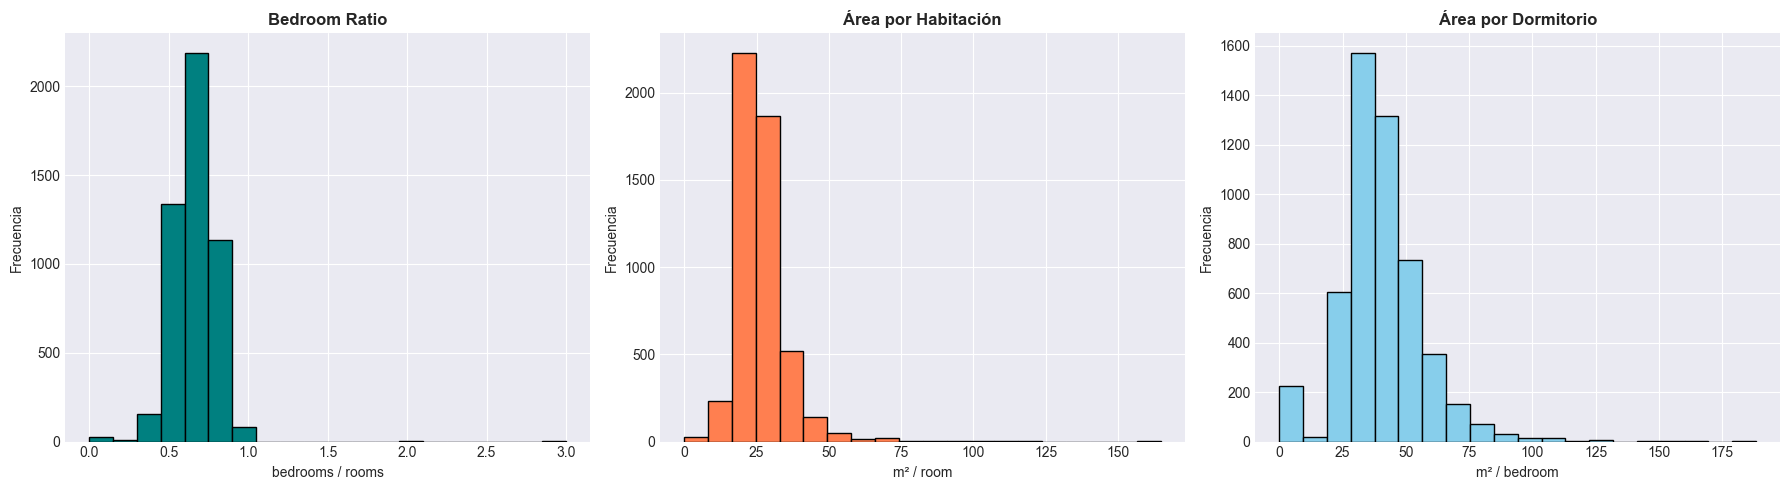

In [55]:
# Features de ratios
print("FEATURES DE RATIOS")

df_temp = df.copy()

# bedroom_ratio = bedrooms / rooms
if 'bedrooms' in df_temp.columns and 'rooms' in df_temp.columns:
    df_temp['bedroom_ratio'] = df_temp.apply(
        lambda row: row['bedrooms'] / row['rooms'] if row['rooms'] > 0 else 0, axis=1
    )
    print(f"bedroom_ratio: {df_temp['bedroom_ratio'].mean():.2f} (promedio)")

# area_per_room = living_area / rooms
if 'living_area' in df_temp.columns and 'rooms' in df_temp.columns:
    df_temp['area_per_room'] = df_temp.apply(
        lambda row: row['living_area'] / row['rooms'] if row['rooms'] > 0 else 0, axis=1
    )
    print(f"area_per_room: {df_temp['area_per_room'].mean():.1f} m² (promedio)")

# area_per_bedroom = living_area / bedrooms
if 'living_area' in df_temp.columns and 'bedrooms' in df_temp.columns:
    df_temp['area_per_bedroom'] = df_temp.apply(
        lambda row: row['living_area'] / row['bedrooms'] if row['bedrooms'] > 0 else 0, axis=1
    )
    print(f"area_per_bedroom: {df_temp['area_per_bedroom'].mean():.1f} m² (promedio)")

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if 'bedroom_ratio' in df_temp.columns:
    axes[0].hist(df_temp['bedroom_ratio'].dropna(), bins=20, color='teal', edgecolor='black')
    axes[0].set_title('Bedroom Ratio', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('bedrooms / rooms')
    axes[0].set_ylabel('Frecuencia')

if 'area_per_room' in df_temp.columns:
    axes[1].hist(df_temp['area_per_room'].dropna(), bins=20, color='coral', edgecolor='black')
    axes[1].set_title('Área por Habitación', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('m² / room')
    axes[1].set_ylabel('Frecuencia')

if 'area_per_bedroom' in df_temp.columns:
    axes[2].hist(df_temp['area_per_bedroom'].dropna(), bins=20, color='skyblue', edgecolor='black')
    axes[2].set_title('Área por Dormitorio', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('m² / bedroom')
    axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 6.5 Features de barrios

FEATURES DE BARRIO
Top 10 barrios por precio medio:
neighborhood  neighborhood_price_mean  neighborhood_property_count
        Zuid             1.072838e+06                         1013
     Centrum             1.025319e+06                          780
     Unknown             8.077961e+05                          152
        Oost             6.341871e+05                          665
        West             6.328092e+05                          697
       Noord             6.273764e+05                          525
  Nieuw-West             5.783485e+05                          769
    Zuidoost             4.134668e+05                          535


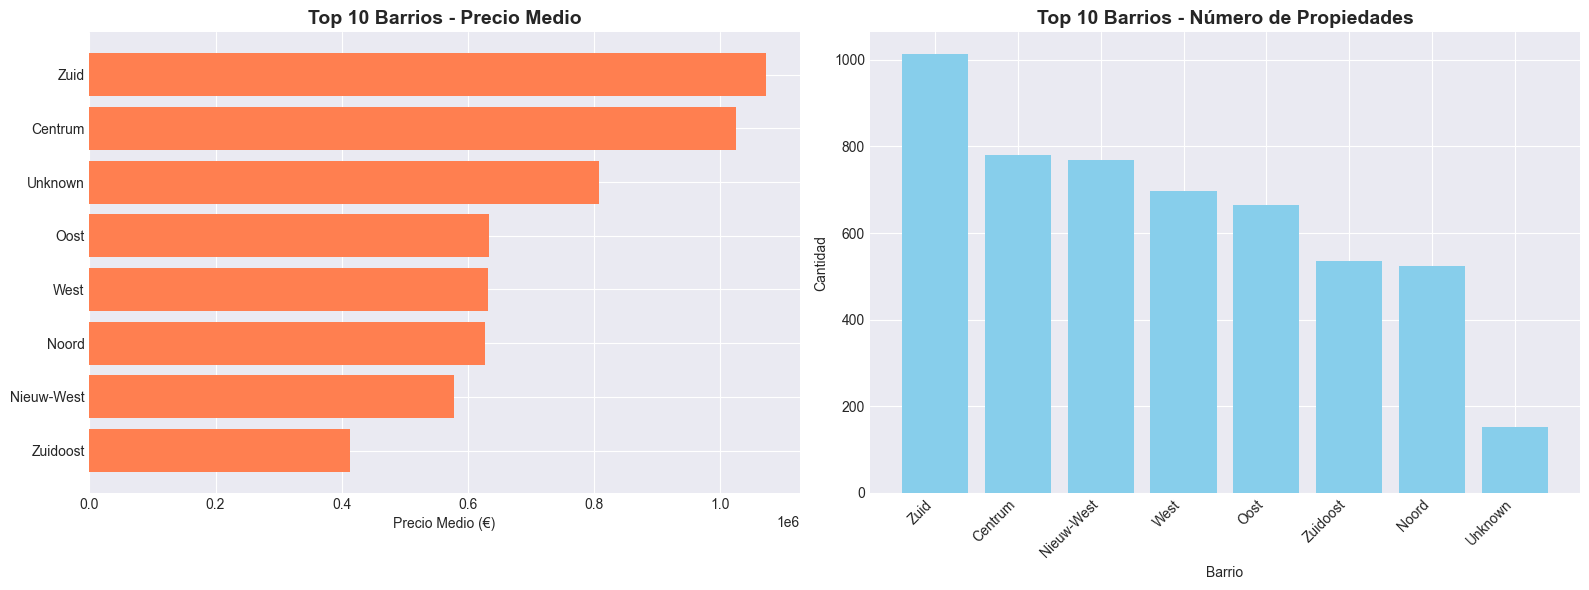

In [56]:
# Estadísticas de barrio (neighborhood_price_mean, etc.)
print("FEATURES DE BARRIO")

if 'neighborhood' in df.columns:
    df_temp = df.copy()
    
    # Crear price_per_m2 temporal si no existe
    if 'price_per_m2' not in df_temp.columns and 'living_area' in df_temp.columns:
        df_temp['price_per_m2'] = df_temp['price'] / df_temp['living_area']
    
    # Calcular estadísticas por barrio
    neighborhood_stats = df_temp.groupby('neighborhood').agg({
        'price': ['mean', 'count'],
        'price_per_m2': 'mean'
    }).reset_index()
    
    neighborhood_stats.columns = [
        'neighborhood',
        'neighborhood_price_mean',
        'neighborhood_property_count',
        'neighborhood_price_sqm_mean'
    ]
    
    # Merge con df_temp para exploración
    df_temp = df_temp.merge(neighborhood_stats, on='neighborhood', how='left')
    
    print("Top 10 barrios por precio medio:")
    print(neighborhood_stats.nlargest(10, 'neighborhood_price_mean')[[
        'neighborhood', 'neighborhood_price_mean', 'neighborhood_property_count'
    ]].to_string(index=False))
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top 10 barrios por precio medio
    top10 = neighborhood_stats.nlargest(10, 'neighborhood_price_mean')
    axes[0].barh(top10['neighborhood'], top10['neighborhood_price_mean'], color='coral')
    axes[0].set_title('Top 10 Barrios - Precio Medio', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Precio Medio (€)')
    axes[0].invert_yaxis()
    
    # Distribución de propiedades por barrio
    top10_count = neighborhood_stats.nlargest(10, 'neighborhood_property_count')
    axes[1].bar(range(len(top10_count)), top10_count['neighborhood_property_count'], color='skyblue')
    axes[1].set_title('Top 10 Barrios - Número de Propiedades', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Cantidad')
    axes[1].set_xlabel('Barrio')
    axes[1].set_xticks(range(len(top10_count)))
    axes[1].set_xticklabels(top10_count['neighborhood'], rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("No hay columna 'neighborhood' disponible")

### 6.6 One-hot encoding de neighborhood

In [57]:
print("ONE-HOT ENCODING DE NEIGHBORHOOD")
print(f"- Shape actual: {df.shape}")
print(f"- Neighborhoods únicos: {df['neighborhood'].nunique()}")

# One-hot encoding
df_temp = pd.get_dummies(df, columns=['neighborhood'], prefix='neighborhood', drop_first=True)

print(f"\n- Shape si se aplicara one-hot: {df_temp.shape}")
print(f"- Nuevas columnas que se crearían: {df_temp.shape[1] - df.shape[1]}")

# Mostrar columnas que se crearían
one_hot_cols = [col for col in df_temp.columns if col.startswith('neighborhood_')]
print(f"\nPrimeras columnas one-hot (simulación):")
print(one_hot_cols[:6])

ONE-HOT ENCODING DE NEIGHBORHOOD
- Shape actual: (5136, 32)
- Neighborhoods únicos: 8

- Shape si se aplicara one-hot: (5136, 38)
- Nuevas columnas que se crearían: 6

Primeras columnas one-hot (simulación):
['neighborhood_Nieuw-West', 'neighborhood_Noord', 'neighborhood_Oost', 'neighborhood_Unknown', 'neighborhood_West', 'neighborhood_Zuid']


---

## 7. Análisis de Correlación

**Análisis de correlaciones entre variables numericas**

### 7.1 Mapa de Calor de Correlación

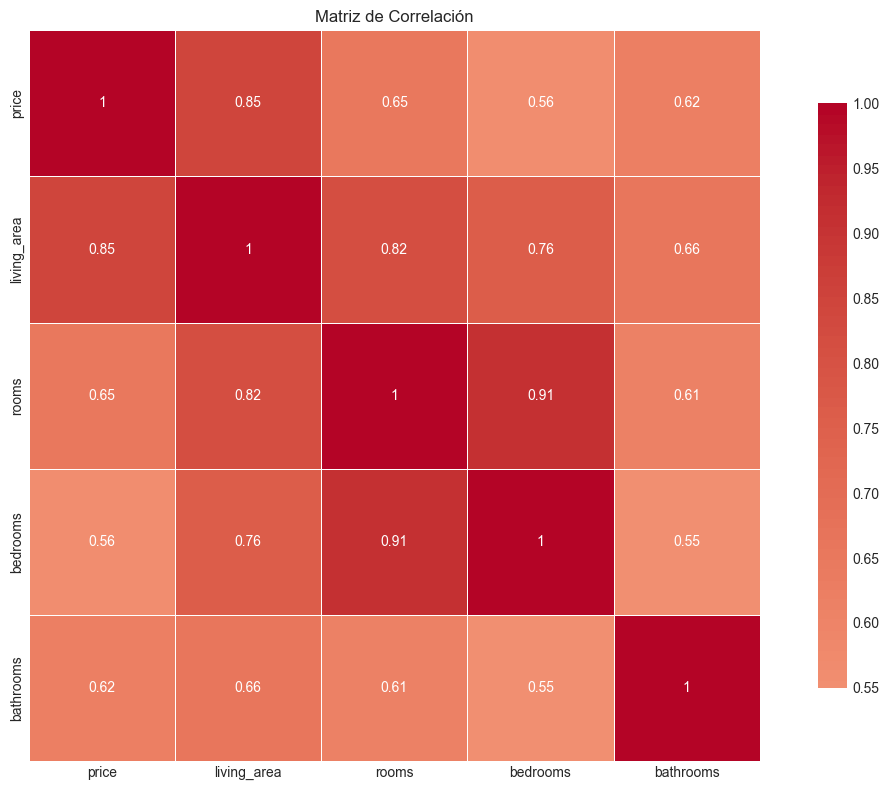

In [58]:
# Mapa de calor de correlaciones
numeric_vars = ['price', 'living_area', 'rooms', 'bedrooms', 'bathrooms']
available = [v for v in numeric_vars if v in df.columns]

if 'price_per_sqm' in df.columns:
    available.append('price_per_sqm')

if len(available) >= 3:
    eda.plot_correlation_heatmap(available)

In [59]:
# Correlaciones con price
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'id']  # Auto-incremento del DB por 'id'

print(f"Variables numericas: {len(numeric_cols)}")

if 'price' in numeric_cols:
    correlations = df[numeric_cols].corr()['price'].sort_values(ascending=False)

    print("\nTop 20 CORRELACIONES CON PRICE:")
    print(correlations.head(20))


Variables numericas: 13

Top 20 CORRELACIONES CON PRICE:
price                   1.000000
predicted_price         0.944201
living_area             0.848816
rooms                   0.651725
bathrooms               0.622426
bedrooms                0.562016
price_per_m2            0.521710
energy_label_encoded    0.016467
latitude                0.003358
has_amenities          -0.001748
longitude              -0.024573
floor                  -0.027021
year_built             -0.169616
Name: price, dtype: float64



Variables con |correlacion| > 0.3: 7


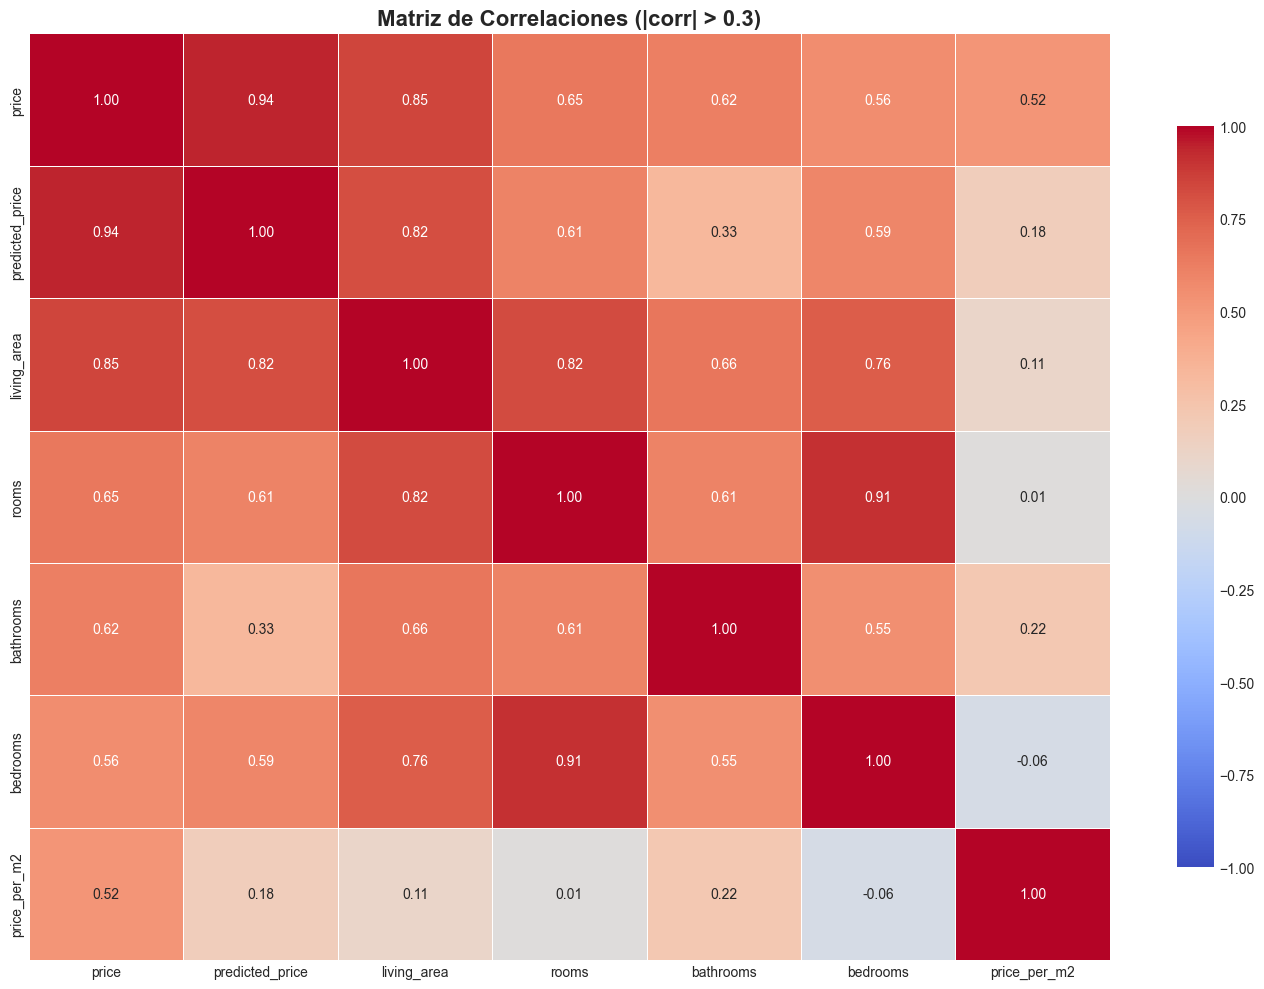

In [60]:
# Heatmap FILTRADO (solo |corr| > 0.3)
if 'price' in numeric_cols:
    high_corr_vars = correlations[abs(correlations) > 0.3].index.tolist()

    if len(high_corr_vars) > 1:
        print(f"\nVariables con |correlacion| > 0.3: {len(high_corr_vars)}")

        corr_matrix_filtered = df[high_corr_vars].corr()

        plt.figure(figsize=(14, 10))
        sns.heatmap(corr_matrix_filtered, annot=True, fmt='.2f', cmap='coolwarm', 
        center=0, linewidths=0.5, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
        plt.title('Matriz de Correlaciones (|corr| > 0.3)', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("\nPocas variables con correlacion alta")

---

## 8. Análisis de Multicolinealidad (VIF)

**Detección iterativa de multicolinealidad en 3 rondas**

In [61]:
# RONDA 1: VIF para TODAS las variables numericas (excepto price, etc.)
print("-" * 80)
print("VIF RONDA 1: TODAS LAS VARIABLES")
print("-" * 80)

# Seleccionar variables para VIF (excepto price, etc.)
vif_vars_round1 = []
for col in numeric_cols:
    # Excluir variables específicas y comprobar que existen
    if (col not in ['price', 'price_per_sqm', 'id', 'latitude', 'longitude', 'price_zone'] and 
        not col.startswith('neighborhood_') and
        col in df.columns):
        # Verificar que tiene suficientes valores no nulos (al menos 80% del dataset)
        if df[col].notna().sum() / len(df) >= 0.8:
            vif_vars_round1.append(col)

print(f"Variables a analizar: {len(vif_vars_round1)}")
print(vif_vars_round1[:20]) # Mostrar primeras 20

if len(vif_vars_round1) >= 2:
    vif_df_r1 = eda.calculate_vif(vif_vars_round1)
    print("\n" + "-" * 80)
    print(vif_df_r1.sort_values('VIF', ascending=False).head(15))
    print("\nCriterio: VIF > 10 indica multicolinealidad ALTA")
else:
    print("Insuficientes variables para VIF")

--------------------------------------------------------------------------------
VIF RONDA 1: TODAS LAS VARIABLES
--------------------------------------------------------------------------------
Variables a analizar: 8
['living_area', 'rooms', 'bedrooms', 'bathrooms', 'year_built', 'price_per_m2', 'energy_label_encoded', 'has_amenities']
Factor de Inflación de Varianza (VIF)
year_built                    :   143.20 -> ALTA multicolinealidad
has_amenities                 :   118.45 -> ALTA multicolinealidad
rooms                         :    45.09 -> ALTA multicolinealidad
bedrooms                      :    28.61 -> ALTA multicolinealidad
living_area                   :    15.03 -> ALTA multicolinealidad
price_per_m2                  :    13.68 -> ALTA multicolinealidad
bathrooms                     :    13.42 -> ALTA multicolinealidad
energy_label_encoded          :     7.96 -> MODERADA multicolinealidad

--------------------------------------------------------------------------------


In [62]:
# RONDA 2: VIF eliminando variables con VIF > 10
print("-" * 80)
print("VIF RONDA 2: ELIMINANDO VIF > 10")
print("-" * 80)

if len(vif_vars_round1) >= 2:
    # Eliminar variables con VIF > 10
    vif_df_r1_sorted = vif_df_r1.sort_values('VIF', ascending=False)
    high_vif_vars = vif_df_r1_sorted[vif_df_r1_sorted['VIF'] > 10]['Variable'].tolist()

    print(f"Variables eliminadas (VIF > 10): {len(high_vif_vars)}")
    if len(high_vif_vars) > 0:
        print(high_vif_vars[:10]) # Mostrar primeras 10

    # Variables restantes
    vif_vars_round2 = [v for v in vif_vars_round1 if v not in high_vif_vars]

    print(f"\nVariables restantes: {len(vif_vars_round2)}")

    if len(vif_vars_round2) >= 2:
        vif_df_r2 = eda.calculate_vif(vif_vars_round2)
        print("\n" + "-" * 80)
        print(vif_df_r2.sort_values('VIF', ascending=False))
    else:
        print("Insuficientes variables para VIF")

--------------------------------------------------------------------------------
VIF RONDA 2: ELIMINANDO VIF > 10
--------------------------------------------------------------------------------
Variables eliminadas (VIF > 10): 7
['year_built', 'has_amenities', 'rooms', 'bedrooms', 'living_area', 'price_per_m2', 'bathrooms']

Variables restantes: 1
Insuficientes variables para VIF


In [63]:
# RONDA 3: VIF FINAL - Solo variables con VIF < 5
print("-" * 80)
print("VIF RONDA 3: SOLO VIF < 5 (FINAL)")
print("-" * 80)

if 'vif_df_r2' in locals() and len(vif_vars_round2) >= 2:
    # Eliminar variables con VIF > 5
    moderate_vif_vars = vif_df_r2[vif_df_r2['VIF'] > 5]['Variable'].tolist()

    print(f"Variables eliminadas (5 < VIF < 10): {len(moderate_vif_vars)}")
    if len(moderate_vif_vars) > 0:
        print(moderate_vif_vars)

    # Variables finales
    vif_vars_final = [v for v in vif_vars_round2 if v not in moderate_vif_vars]

    print(f"\nVariables FINALES (VIF < 5): {len(vif_vars_final)}")

    if len(vif_vars_final) >= 2:
        vif_df_final = eda.calculate_vif(vif_vars_final)
        print("\n" + "-" * 80)
        print(" " * 25 + "VIF FINAL")
        print(vif_df_final.sort_values('VIF', ascending=False))
        print("\nTODAS las variables tienen VIF < 5 (Multicolinealidad aceptable)")
    else:
        print("Solo quedan 1-2 variables principales")
        print(vif_vars_final)
else:
    print("Insuficientes variables para VIF")

--------------------------------------------------------------------------------
VIF RONDA 3: SOLO VIF < 5 (FINAL)
--------------------------------------------------------------------------------
Insuficientes variables para VIF


---

## 9. Transformación Logarítmica del Target

Transformación a escala logarítmica de la variable precio.

`price` -> `log1p(price)`


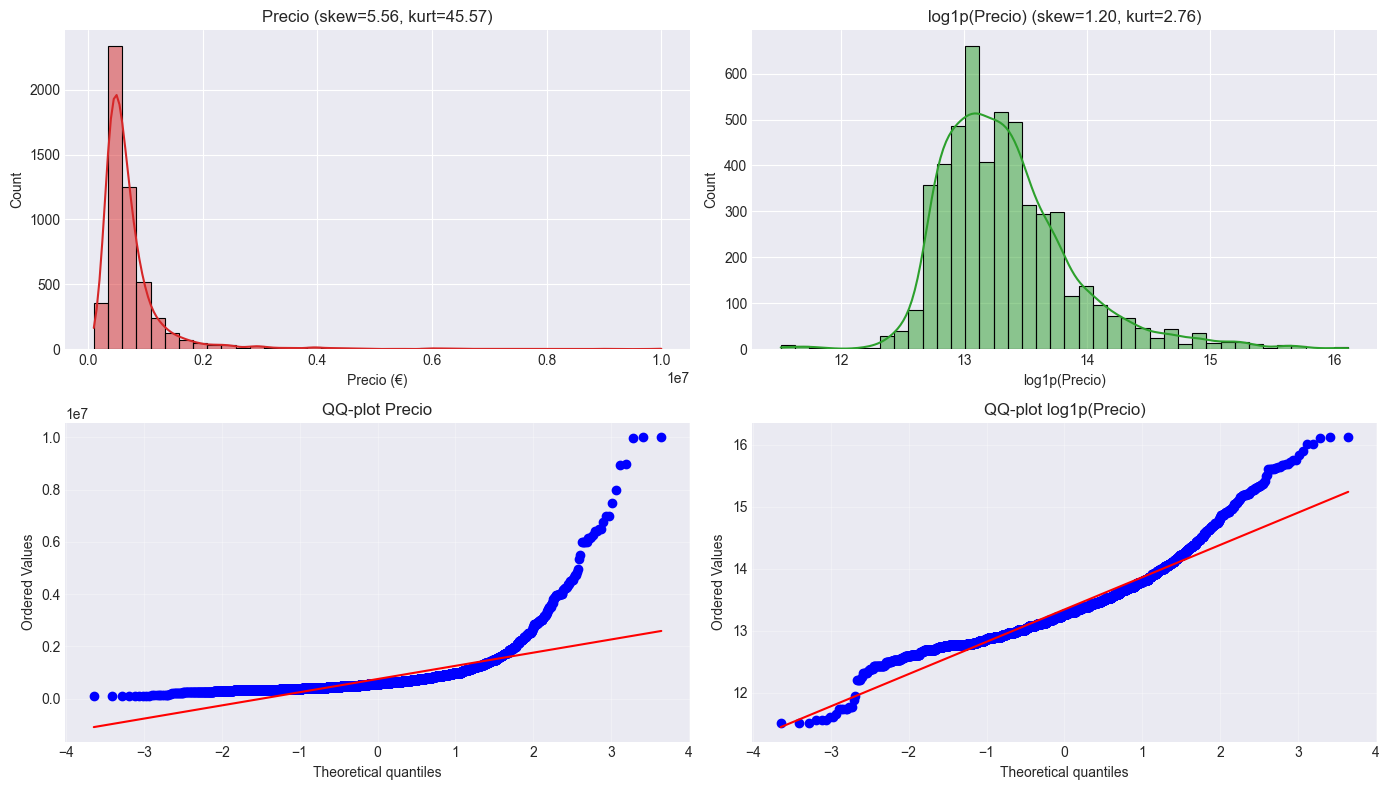


Shapiro-Wilk price:        stat=0.5124 | p-value=1.321463e-79  (n=5,000)
Shapiro-Wilk log1p(price): stat=0.9228 | p-value=5.801567e-45  (n=5,000)


In [64]:
import numpy as np
from scipy.stats import skew, kurtosis, shapiro

# Comparativa: distribución original vs log-transformada
y = df['price']
y_log = np.log1p(y)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Histograma original
sns.histplot(y, bins=40, kde=True, ax=axes[0, 0], color='tab:red')
axes[0, 0].set_title(f'Precio (skew={skew(y.dropna()):.2f}, kurt={kurtosis(y.dropna()):.2f})')
axes[0, 0].set_xlabel('Precio (€)')

# Histograma log
sns.histplot(y_log, bins=40, kde=True, ax=axes[0, 1], color='tab:green')
axes[0, 1].set_title(f'log1p(Precio) (skew={skew(y_log.dropna()):.2f}, kurt={kurtosis(y_log.dropna()):.2f})')
axes[0, 1].set_xlabel('log1p(Precio)')

# QQ-plot original
stats.probplot(y.dropna(), dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot Precio')
axes[1, 0].grid(True, alpha=0.3)

# QQ-plot log
stats.probplot(y_log.dropna(), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('QQ-plot log1p(Precio)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Shapiro-Wilk en ambas escalas
y_clean = y.dropna()
y_log_clean = y_log.dropna()
n_orig = min(5000, len(y_clean))
n_log = min(5000, len(y_log_clean))

stat_orig, p_orig = shapiro(y_clean.sample(n_orig, random_state=42))
stat_log, p_log = shapiro(y_log_clean.sample(n_log, random_state=42))

print(f'\nShapiro-Wilk price:        stat={stat_orig:.4f} | p-value={p_orig:.6e}  (n={n_orig:,})')
print(f'Shapiro-Wilk log1p(price): stat={stat_log:.4f} | p-value={p_log:.6e}  (n={n_log:,})')
